# Surrogate Optimisation Investigation

This concerns the optimisation of $I(T(X);Y)$ in the case of SR, and $I(T(X);Y_{\text{PS}})$ in the case of GBSR — this avoids the non-smoothness of the `hard-min` error formulation. With the appropriate ($V_\text{mod}, \mathbf{\tau}$) found, we can then evaluate the practical key rate using the $h(e_2)$ formulation. (See reconciliation efficiency notes).

We'll start with SR. Let $m$ be the number of bits per symbol, $K = 2^m$ the number of quantisation intervals, and $\boldsymbol{\tau} = (\tau_0,\dots,\tau_K)$ the ordered bin edges with $\tau_0 = -\infty$, $\tau_K = +\infty$. The modulation variance is $V_{\text{mod}}$ (so $\sigma_X = \sqrt{V_{\text{mod}}}$). We optimise over $(V_{\text{mod}},\boldsymbol{\tau})$.

Then we move on to GBSR, which is the same as SR except for the additional optimisation of $g_{\pm,i}$ (see main.pdf).

As a reminder for SR, we are investigating optimsing $K := I(T;Y) - \chi(V_{\text{mod}})$, rather than $K = H(T(X)) - \sum_{i=1}^m \big(1-\eta_{c,i}\big(1-h_2(e_i)\big)\big) - \chi(V_{\text{mod}})$, because the latter is not smooth due to the `hard-min` in $e_i$. The former is smooth because $I(T;Y)$ is smooth (as we will see).


## Parameters, Preamble, Etc

In [58]:
import numpy as np
from scipy.stats import norm
from scipy.optimize import minimize, minimize_scalar
from scipy import integrate
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import importlib

SR = importlib.import_module('guard_band_postselection.SR').SR
GBSR = importlib.import_module('guard_band_postselection.GBSR').GBSR
MD = importlib.import_module('guard_band_postselection.MD').MD

v_mod_bounds = (0.001, 30.0)
excess_noise = 0.005
Delta_QCT = 0.0
eta_c = 0.97  # coding efficiency (constant for now)
distances_km = np.logspace(-2, np.log10(50), num=100)

def fibre_transmittance(distance_km, loss_db_per_km=0.2):
    """Return the channel transmittance for a fibre segment of length `distance_km`."""
    return 10 ** (-loss_db_per_km * distance_km / 10)


## Excess Noise

Quadratic fit coefficients: a=6.518e-06, b=1.366e-04, c=1.257e-02


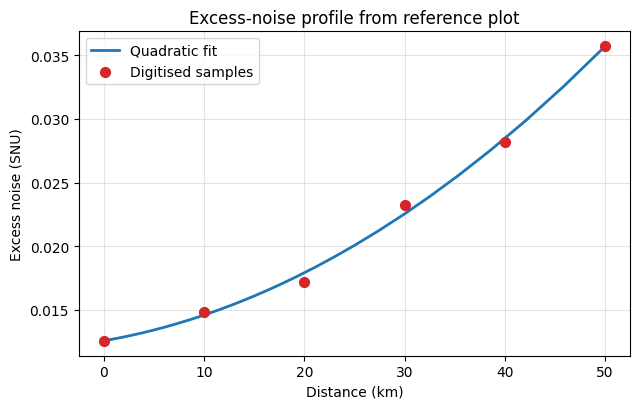

In [59]:
"""Approximate the excess-noise curve from the reference plot and fit a quadratic."""
import numpy as np
import matplotlib.pyplot as plt

# Approximate red data points (distance in km vs. excess noise) read from the figure.
# These values were digitised by eye, so treat them as order-of-magnitude guidance.
distance_samples_km = np.array([0, 10, 20, 30, 40, 50])
excess_noise_samples = np.array([
    0.012555178268251276,
    0.014847198641765706,
    0.017224108658743634,
    0.023251273344651956,
    0.028174872665534808,
    0.03573005093378608,
])

# Quadratic fit
quad_coeffs = np.polyfit(distance_samples_km, excess_noise_samples, deg=2)
excess_noise_fit = np.poly1d(quad_coeffs)

# Evaluate the polynomial on a dense grid for plotting and future reuse.
excess_noise_dense = excess_noise_fit(distances_km)

# Coefficient diagnostics (a * d^2 + b * d + c)
a, b, c = quad_coeffs
print(f"Quadratic fit coefficients: a={a:.3e}, b={b:.3e}, c={c:.3e}")

# Plot: continuous fit plus the discrete points with error bars.
fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.plot(distances_km, excess_noise_dense, color='tab:blue', linewidth=2.0, label='Quadratic fit')
# Overlay the digitised sample points so the raw data are visible
ax.scatter(distance_samples_km, excess_noise_samples, color='tab:red', marker='o', s=50, zorder=3, label='Digitised samples')
ax.set_xlabel('Distance (km)')
ax.set_ylabel('Excess noise (SNU)')
ax.set_title('Excess-noise profile from reference plot')
ax.grid(True, alpha=0.35)
ax.legend()
fig.tight_layout()

# Store artefacts for downstream optimisation code.
excess_noise_profile = {
    "samples_km": distance_samples_km,
    "samples_noise": excess_noise_samples,
    "fit_coeffs": quad_coeffs,
    "fit_poly": excess_noise_fit,
}

In [60]:
"""Efficient excess-noise lookup derived from the quadratic fit above."""
from functools import lru_cache
from typing import Sequence, Union

distance_min_km = float(distance_samples_km.min())
distance_max_km = float(distance_samples_km.max())

def _prepare_distances(distance_km: Union[float, Sequence[float], np.ndarray], clamp: bool) -> np.ndarray:
    distances = np.asarray(distance_km, dtype=float)
    if clamp:
        distances = np.clip(distances, distance_min_km, distance_max_km)
    return distances

@lru_cache(maxsize=512)
def _excess_noise_scalar(distance_km: float, clamp: bool) -> float:
    distance = distance_km
    if clamp:
        distance = float(np.clip(distance, distance_min_km, distance_max_km))
    return float(excess_noise_fit(distance))

def excess_noise_from_distance(distance_km: Union[float, Sequence[float], np.ndarray], *, clamp: bool = True) -> Union[float, np.ndarray]:
    """Return excess noise (SNU) for the provided fibre distance in km.

    Parameters
    ----------
    distance_km
        Fibre distance(s) in kilometres; accepts scalars, lists, or numpy arrays.
    clamp
        Constrain the evaluation to the calibrated range
        [$distance_min_km$, $distance_max_km$] to avoid unstable extrapolation.

    Returns
    -------
    float or np.ndarray
        Excess-noise estimate(s) in shot-noise units.
    """
    if np.isscalar(distance_km):
        return _excess_noise_scalar(float(distance_km), clamp)

    distances = _prepare_distances(distance_km, clamp)
    return excess_noise_fit(distances)

# Make the callable discoverable to downstream analysis.
excess_noise_profile["callable"] = excess_noise_from_distance

## SR

### Devetak-Winter Sanity Check

SR m=1 Devetak-Winter:   0%|          | 0/100 [00:00<?, ?it/s]

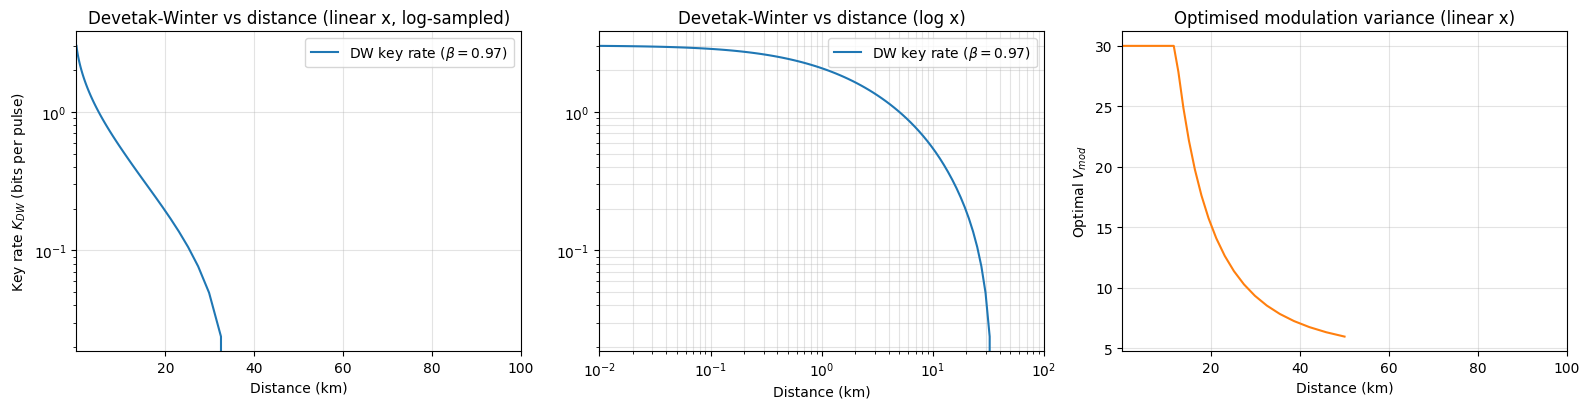

In [61]:
"""Optimise SR m=1 Devetak-Winter key rate with distance-dependent excess noise."""
beta_dw = 0.97
optimal_vmods_DW = []
dw_key_rates = []
mutual_infos = []
holevo_terms = []
excess_noise_trace = []

progress_iter = tqdm(distances_km, desc="SR m=1 Devetak-Winter", leave=False)
for distance_km in progress_iter:
    T = fibre_transmittance(distance_km)
    xi_excess = float(excess_noise_from_distance(distance_km))
    excess_noise_trace.append(xi_excess)

    def neg_dw_key_rate(v_mod):
        sr_instance = SR(
            m=1,
            modulation_variance=float(v_mod),
            transmittance=float(T),
            excess_noise=xi_excess,
            Delta_QCT=Delta_QCT,
            code_efficiency=eta_c,
        )
        return -sr_instance.evaluate_devetak_winter(beta=beta_dw)

    result = minimize_scalar(neg_dw_key_rate, bounds=v_mod_bounds, method="bounded")
    if not result.success:
        raise RuntimeError(f'V_mod optimisation failed at distance {distance_km} km: {result.message}')
    v_opt = float(result.x)
    optimal_vmods_DW.append(v_opt)

    sr_opt = SR(
        m=1,
        modulation_variance=v_opt,
        transmittance=float(T),
        excess_noise=xi_excess,
        Delta_QCT=Delta_QCT,
        code_efficiency=eta_c,
    )
    dw_rate = sr_opt.evaluate_devetak_winter(beta=beta_dw)
    dw_key_rates.append(dw_rate)
    mutual_infos.append(sr_opt.I_AB)
    holevo_terms.append(sr_opt._holevo_with_qct())

# --- plotting: key rate (linear x), key rate (log x), V_mod (linear x) ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
ax_k_lin, ax_k_log, ax_vmod = axes

# Key rate linear x (points are log-sampled)
ax_k_lin.plot(distances_km, dw_key_rates, label='DW key rate ($\\beta=0.97$)')
ax_k_lin.set_xlabel('Distance (km)')
ax_k_lin.set_ylabel('Key rate $K_{DW}$ (bits per pulse)')
ax_k_lin.set_title('Devetak-Winter vs distance (linear x, log-sampled)')
ax_k_lin.set_yscale('log')
ax_k_lin.set_xlim(1e-2, 1e2)
ax_k_lin.grid(True, alpha=0.35)
ax_k_lin.legend()

# Key rate log x
ax_k_log.plot(distances_km, dw_key_rates, label='DW key rate ($\\beta=0.97$)')
ax_k_log.set_xlabel('Distance (km)')
ax_k_log.set_title('Devetak-Winter vs distance (log x)')
ax_k_log.set_yscale('log')
ax_k_log.set_xscale('log')
ax_k_log.set_xlim(1e-2, 1e2)
ax_k_log.grid(True, which='both', alpha=0.35)
ax_k_log.legend()

# V_mod linear x
ax_vmod.plot(distances_km, optimal_vmods_DW, color='tab:orange')
ax_vmod.set_xlabel('Distance (km)')
ax_vmod.set_ylabel('Optimal $V_{mod}$')
ax_vmod.set_title('Optimised modulation variance (linear x)')
ax_vmod.set_xlim(1e-2, 1e2)
ax_vmod.grid(True, alpha=0.35)

fig.tight_layout()

In [62]:
# Compute SR m = 1 'true' key rate (direct optimisation) for reuse upstream
tau_sr_m1 = [-np.inf, 0.0, np.inf]

true_m1_vmods = []
true_m1_key_rates = []
true_m1_etas = []
true_m1_error_rates = []
true_m1_bits_leaked = []
true_m1_bits_sent = []
true_m1_holevo = []
true_m1_excess_noise = []

progress_iter = tqdm(distances_km, desc="SR m=1 actual", leave=False)
for distance_km in progress_iter:
    T = fibre_transmittance(distance_km)
    xi_excess = float(excess_noise_from_distance(distance_km))
    true_m1_excess_noise.append(xi_excess)

    def neg_key_rate(v_mod):
        sr_instance = SR(
            m=1,
            modulation_variance=float(v_mod),
            transmittance=float(T),
            excess_noise=xi_excess,
            Delta_QCT=Delta_QCT,
            code_efficiency=eta_c,
        )
        return -sr_instance.evaluate_key_rate_in_bits_per_pulse(tau_sr_m1)

    result = minimize_scalar(neg_key_rate, bounds=v_mod_bounds, method="bounded")
    if not result.success:
        raise RuntimeError(
            f"V_mod optimisation (true m=1) failed at distance {distance_km} km: {result.message}"
        )

    v_opt = float(result.x)
    true_m1_vmods.append(v_opt)

    sr_opt = SR(
        m=1,
        modulation_variance=v_opt,
        transmittance=float(T),
        excess_noise=xi_excess,
        Delta_QCT=Delta_QCT,
        code_efficiency=eta_c,
    )

    key_rate = sr_opt.evaluate_key_rate_in_bits_per_pulse(tau_sr_m1)
    true_m1_key_rates.append(key_rate)

    metrics = sr_opt.evaluate_reconciliation_efficiency(tau_sr_m1)
    true_m1_etas.append(metrics["eta"])
    slice_info = metrics["slices"][0]
    true_m1_error_rates.append(slice_info["error_rate"])
    true_m1_bits_leaked.append(metrics["bits_leaked"])
    true_m1_bits_sent.append(metrics["bits_sent"])
    true_m1_holevo.append(sr_opt._holevo_with_qct())

true_m1_vmods = np.array(true_m1_vmods)
true_m1_key_rates = np.array(true_m1_key_rates)
true_m1_etas = np.array(true_m1_etas)
true_m1_error_rates = np.array(true_m1_error_rates)
true_m1_bits_leaked = np.array(true_m1_bits_leaked)
true_m1_bits_sent = np.array(true_m1_bits_sent)
true_m1_holevo = np.array(true_m1_holevo)
true_m1_excess_noise = np.array(true_m1_excess_noise)

SR m=1 actual:   0%|          | 0/100 [00:00<?, ?it/s]

### SR $m=1$ (Simplest Case)

In this case, the 'naive' or 'true' method of optimisation is also smooth. So, we will compare the two. First, we run the usual $h_2(e)$ method:

SR m=1 direct:   0%|          | 0/100 [00:00<?, ?it/s]

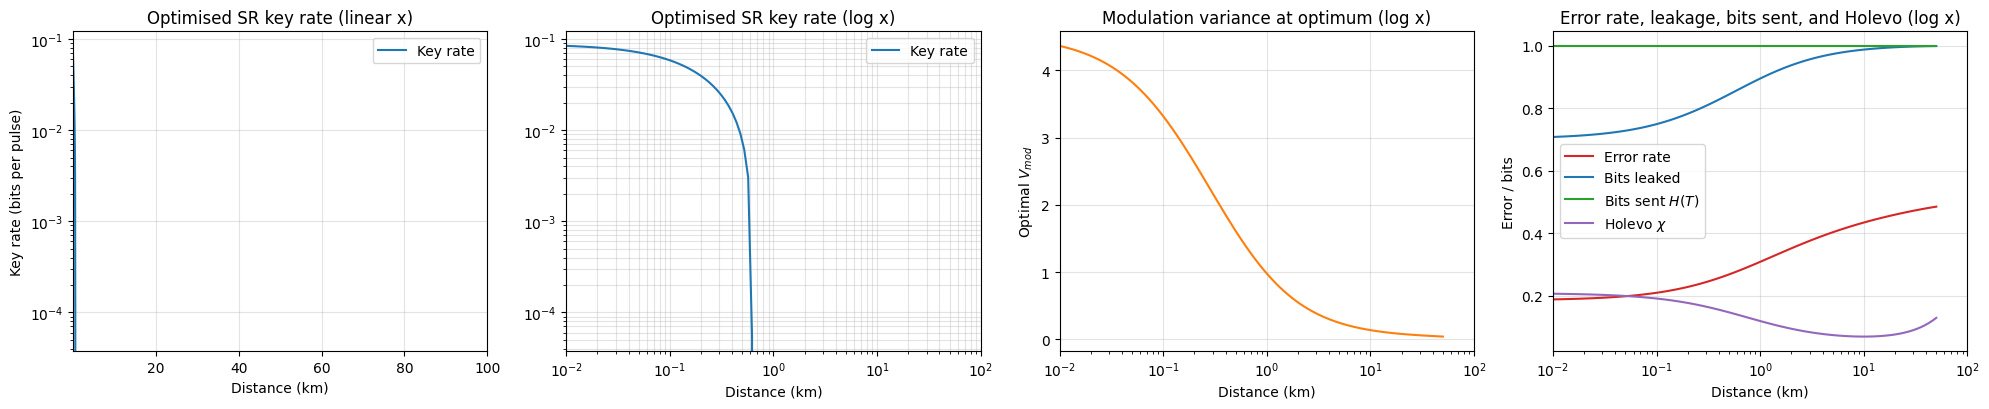

In [63]:
# SR m = 1
tau_sr_m1 = [-np.inf, 0.0, np.inf]

optimal_vmods_DW = []
optimal_key_rates = []
optimal_etas = []
optimal_error_rates = []
optimal_bits_leaked = []
optimal_bits_sent = []
optimal_holevo = []
optimal_excess_noise = []

progress_iter = tqdm(distances_km, desc="SR m=1 direct", leave=False)
for distance_km in progress_iter:
    T = fibre_transmittance(distance_km)
    xi_excess = float(excess_noise_from_distance(distance_km))
    optimal_excess_noise.append(xi_excess)

    def neg_key_rate(v_mod):
        sr_instance = SR(
            m=1,
            modulation_variance=float(v_mod),
            transmittance=float(T),
            excess_noise=xi_excess,
            Delta_QCT=Delta_QCT,
            code_efficiency=eta_c,
        )
        return -sr_instance.evaluate_key_rate_in_bits_per_pulse(tau_sr_m1)

    result = minimize_scalar(neg_key_rate, bounds=v_mod_bounds, method="bounded")
    if not result.success:
        raise RuntimeError(
            f'V_mod optimisation failed at distance {distance_km} km: {result.message}'
        )

    v_opt = float(result.x)
    optimal_vmods_DW.append(v_opt)

    sr_opt = SR(
        m=1,
        modulation_variance=v_opt,
        transmittance=float(T),
        excess_noise=xi_excess,
        Delta_QCT=Delta_QCT,
        code_efficiency=eta_c,
    )

    key_rate = sr_opt.evaluate_key_rate_in_bits_per_pulse(tau_sr_m1)
    optimal_key_rates.append(key_rate)

    metrics = sr_opt.evaluate_reconciliation_efficiency(tau_sr_m1)
    optimal_etas.append(metrics["eta"])
    slice_info = metrics["slices"][0]
    optimal_error_rates.append(slice_info["error_rate"])
    optimal_bits_leaked.append(metrics["bits_leaked"])
    optimal_bits_sent.append(metrics["bits_sent"])
    optimal_holevo.append(sr_opt._holevo_with_qct())

optimal_vmods_DW = np.array(optimal_vmods_DW)
optimal_key_rates = np.array(optimal_key_rates)
optimal_etas = np.array(optimal_etas)
optimal_error_rates = np.array(optimal_error_rates)
optimal_bits_leaked = np.array(optimal_bits_leaked)
optimal_bits_sent = np.array(optimal_bits_sent)
optimal_holevo = np.array(optimal_holevo)
optimal_excess_noise = np.array(optimal_excess_noise)

# --- plotting: 4 panels -> key (linear x), key (log x), V_mod (linear x), leak metrics (linear x)
fig, axes = plt.subplots(1, 4, figsize=(20, 4.2))
ax_key_lin, ax_key_log, ax_vmod, ax_leak = axes

# Key rate linear x (data sampled on a log grid)
ax_key_lin.plot(distances_km, optimal_key_rates, label='Key rate')
ax_key_lin.set_xlabel('Distance (km)')
ax_key_lin.set_ylabel('Key rate (bits per pulse)')
ax_key_lin.set_title('Optimised SR key rate (linear x)')
ax_key_lin.set_yscale('log')
ax_key_lin.set_xscale('linear')
ax_key_lin.set_xlim(1e-2, 1e2)
ax_key_lin.grid(True, alpha=0.35)
ax_key_lin.legend()

# Key rate log x
ax_key_log.plot(distances_km, optimal_key_rates, label='Key rate')
ax_key_log.set_xlabel('Distance (km)')
ax_key_log.set_title('Optimised SR key rate (log x)')
ax_key_log.set_yscale('log')
ax_key_log.set_xscale('log')
ax_key_log.set_xlim(1e-2, 1e2)
ax_key_log.grid(True, which='both', alpha=0.35)
ax_key_log.legend()

# V_mod switch x axis to log (was linear); remove marker
ax_vmod.plot(distances_km, optimal_vmods_DW, color='tab:orange')
ax_vmod.set_xlabel('Distance (km)')
ax_vmod.set_ylabel('Optimal $V_{mod}$')
ax_vmod.set_title('Modulation variance at optimum (log x)')
ax_vmod.set_xscale('log')
ax_vmod.set_xlim(1e-2, 1e2)
ax_vmod.grid(True, alpha=0.35)

# Error / leakage / bits / Holevo switch x axis to log (was linear); remove markers
ax_leak.plot(distances_km, optimal_error_rates, color='tab:red', label='Error rate')
ax_leak.plot(distances_km, optimal_bits_leaked, color='tab:blue', label='Bits leaked')
ax_leak.plot(distances_km, optimal_bits_sent, color='tab:green', label='Bits sent $H(T)$')
ax_leak.plot(distances_km, optimal_holevo, color='tab:purple', label='Holevo $\\chi$')
ax_leak.set_xlabel('Distance (km)')
ax_leak.set_ylabel('Error / bits')
ax_leak.set_title('Error rate, leakage, bits sent, and Holevo (log x)')
ax_leak.set_xscale('log')
ax_leak.set_xlim(1e-2, 1e2)
ax_leak.grid(True, alpha=0.35)
ax_leak.legend()

fig.tight_layout()

Okay, now, we run the surrogate method, and try to retrieve similar results.

SR m=1 surrogate:   0%|          | 0/100 [00:00<?, ?it/s]

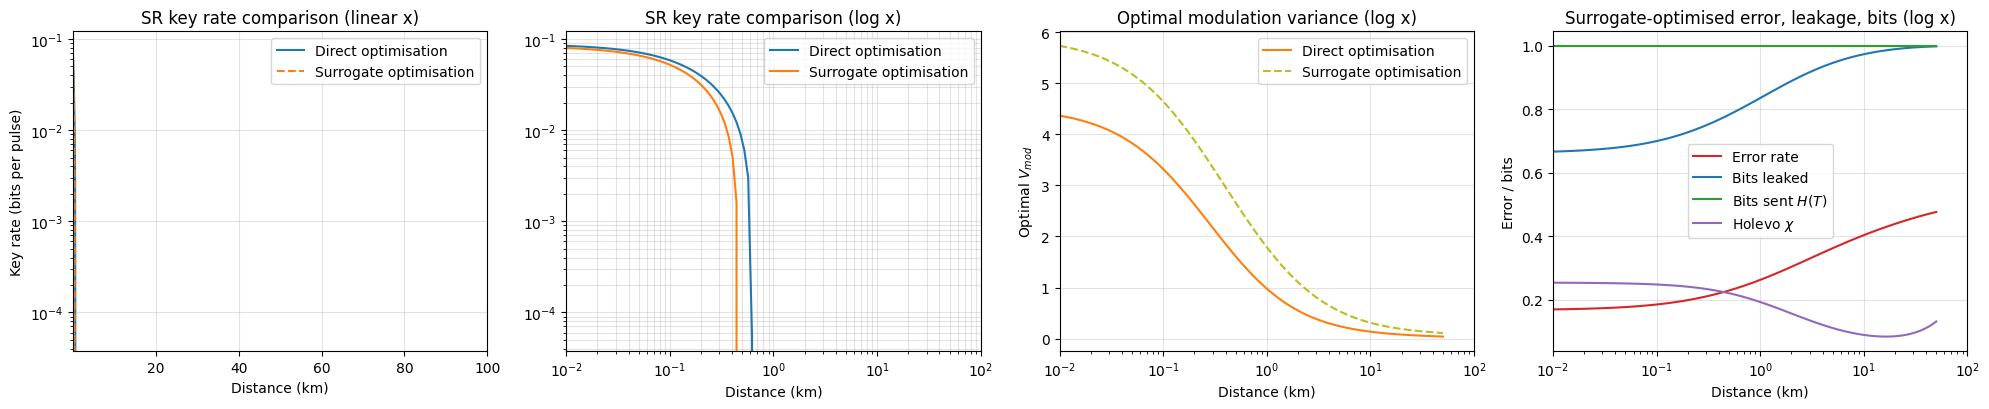

In [64]:
# SR surrogate optimisation via mutual-information objective

from scipy.special import ndtr

herm_nodes, herm_weights = np.polynomial.hermite.hermgauss(240)

def conditional_entropy_T_given_Y(sr_instance, tau_arr, *, nodes=herm_nodes, weights=herm_weights):
    tau_physical = np.asarray(tau_arr, dtype=float) * np.sqrt(sr_instance.modulation_variance)
    var_x = sr_instance.modulation_variance
    var_y = sr_instance.bob_variance
    cov_xy = sr_instance.cov_mat[0, 1]
    cond_var = max(var_x - (cov_xy ** 2) / var_y, 1e-12)
    cond_sigma = np.sqrt(cond_var)
    mu_factor = cov_xy / var_y

    y_samples = np.sqrt(2.0 * var_y) * nodes
    mu = mu_factor * y_samples[:, None]
    z = (tau_physical[None, :] - mu) / cond_sigma
    cdf_vals = ndtr(z)
    interval_probs = np.diff(cdf_vals, axis=1)
    interval_probs = np.clip(interval_probs, 0.0, 1.0)
    log_probs = np.zeros_like(interval_probs)
    np.log2(interval_probs, out=log_probs, where=interval_probs > 0.0)
    entropy_terms = -interval_probs * log_probs

    prefactor = 1.0 / np.sqrt(np.pi)
    return prefactor * np.dot(weights, entropy_terms.sum(axis=1))

def surrogate_key_components(sr_instance, tau_arr):
    quant_entropy = sr_instance.evaluate_quantisation_entropy(tau_arr)
    cond_entropy = conditional_entropy_T_given_Y(sr_instance, tau_arr)
    mutual_information = quant_entropy - cond_entropy
    holevo = sr_instance._holevo_with_qct()
    return mutual_information - holevo, mutual_information, quant_entropy, cond_entropy, holevo

surrogate_optimal_vmods = []
surrogate_m1_actual_key_rates = []
surrogate_surrogate_rates = []
surrogate_mutual_infos = []
surrogate_quant_entropies = []
surrogate_conditional_entropies = []
surrogate_holevo = []
surrogate_etas = []
surrogate_error_rates = []
surrogate_bits_leaked = []
surrogate_bits_sent = []
surrogate_excess_noise = []

progress_iter = tqdm(distances_km, desc="SR m=1 surrogate", leave=False)
for distance_km in progress_iter:
    T = fibre_transmittance(distance_km)
    xi_excess = float(excess_noise_from_distance(distance_km))
    surrogate_excess_noise.append(xi_excess)

    def neg_surrogate_rate(v_mod):
        sr_candidate = SR(
            m=1,
            modulation_variance=float(v_mod),
            transmittance=float(T),
            excess_noise=xi_excess,
            Delta_QCT=Delta_QCT,
            code_efficiency=eta_c,
        )
        surrogate_rate, *_ = surrogate_key_components(sr_candidate, tau_sr_m1)
        return -surrogate_rate

    result = minimize_scalar(neg_surrogate_rate, bounds=v_mod_bounds, method="bounded")
    if not result.success:
        raise RuntimeError(
            f"Surrogate optimisation failed at distance {distance_km} km: {result.message}"
        )

    v_opt = float(result.x)
    surrogate_optimal_vmods.append(v_opt)

    sr_opt = SR(
        m=1,
        modulation_variance=v_opt,
        transmittance=float(T),
        excess_noise=xi_excess,
        Delta_QCT=Delta_QCT,
        code_efficiency=eta_c,
    )

    surrogate_rate, mutual_information, quant_entropy, cond_entropy, holevo = surrogate_key_components(sr_opt, tau_sr_m1)
    surrogate_surrogate_rates.append(surrogate_rate)
    surrogate_mutual_infos.append(mutual_information)
    surrogate_quant_entropies.append(quant_entropy)
    surrogate_conditional_entropies.append(cond_entropy)
    surrogate_holevo.append(holevo)

    metrics = sr_opt.evaluate_reconciliation_efficiency(tau_sr_m1)
    surrogate_m1_actual_key_rates.append(metrics["key_rate"])
    surrogate_etas.append(metrics["eta"])
    slice_info = metrics["slices"][0]
    surrogate_error_rates.append(slice_info["error_rate"])
    surrogate_bits_leaked.append(metrics["bits_leaked"])
    surrogate_bits_sent.append(metrics["bits_sent"])

surrogate_optimal_vmods = np.array(surrogate_optimal_vmods)
surrogate_m1_actual_key_rates = np.array(surrogate_m1_actual_key_rates)
surrogate_surrogate_rates = np.array(surrogate_surrogate_rates)
surrogate_mutual_infos = np.array(surrogate_mutual_infos)
surrogate_quant_entropies = np.array(surrogate_quant_entropies)
surrogate_conditional_entropies = np.array(surrogate_conditional_entropies)
surrogate_holevo = np.array(surrogate_holevo)
surrogate_etas = np.array(surrogate_etas)
surrogate_error_rates = np.array(surrogate_error_rates)
surrogate_bits_leaked = np.array(surrogate_bits_leaked)
surrogate_bits_sent = np.array(surrogate_bits_sent)
surrogate_excess_noise = np.array(surrogate_excess_noise)

fig, axes = plt.subplots(1, 4, figsize=(20, 4.2))
ax_key_lin, ax_key_log, ax_vmod, ax_leak = axes

ax_key_lin.plot(distances_km, optimal_key_rates, label='Direct optimisation')
ax_key_lin.plot(distances_km, surrogate_m1_actual_key_rates, linestyle='--', label='Surrogate optimisation')
ax_key_lin.set_xlabel('Distance (km)')
ax_key_lin.set_ylabel('Key rate (bits per pulse)')
ax_key_lin.set_title('SR key rate comparison (linear x)')
ax_key_lin.set_yscale('log')
ax_key_lin.set_xscale('linear')
ax_key_lin.set_xlim(1e-2, 1e2)
ax_key_lin.grid(True, alpha=0.35)
ax_key_lin.legend()

ax_key_log.plot(distances_km, optimal_key_rates, label='Direct optimisation')
ax_key_log.plot(distances_km, surrogate_m1_actual_key_rates, label='Surrogate optimisation')
ax_key_log.set_xlabel('Distance (km)')
ax_key_log.set_title('SR key rate comparison (log x)')
ax_key_log.set_yscale('log')
ax_key_log.set_xscale('log')
ax_key_log.set_xlim(1e-2, 1e2)
ax_key_log.grid(True, which='both', alpha=0.35)
ax_key_log.legend()

ax_vmod.plot(distances_km, optimal_vmods_DW, label='Direct optimisation', color='tab:orange')
ax_vmod.plot(distances_km, surrogate_optimal_vmods, linestyle='--', label='Surrogate optimisation', color='tab:olive')
ax_vmod.set_xlabel('Distance (km)')
ax_vmod.set_ylabel('Optimal $V_{mod}$')
ax_vmod.set_title('Optimal modulation variance (log x)')
ax_vmod.set_xscale('log')
ax_vmod.set_xlim(1e-2, 1e2)
ax_vmod.grid(True, alpha=0.35)
ax_vmod.legend()

ax_leak.plot(distances_km, surrogate_error_rates, color='tab:red', label='Error rate')
ax_leak.plot(distances_km, surrogate_bits_leaked, color='tab:blue', label='Bits leaked')
ax_leak.plot(distances_km, surrogate_bits_sent, color='tab:green', label='Bits sent $H(T)$')
ax_leak.plot(distances_km, surrogate_holevo, color='tab:purple', label='Holevo $\\chi$')
ax_leak.set_xlabel('Distance (km)')
ax_leak.set_ylabel('Error / bits')
ax_leak.set_title('Surrogate-optimised error, leakage, bits (log x)')
ax_leak.set_xscale('log')
ax_leak.set_xlim(1e-2, 1e2)
ax_leak.grid(True, alpha=0.35)
ax_leak.legend()

fig.tight_layout()

### SR $m = 2$

Now, we peform the surrogate optimisation for $m=2$ bits per symbol. Note that we do not optimise over the $\text{LEAK}_\text{EC}$ term here anymore (it's been non, smooth and unstable recently.)

SR m=2 surrogate:   0%|          | 0/100 [00:00<?, ?it/s]

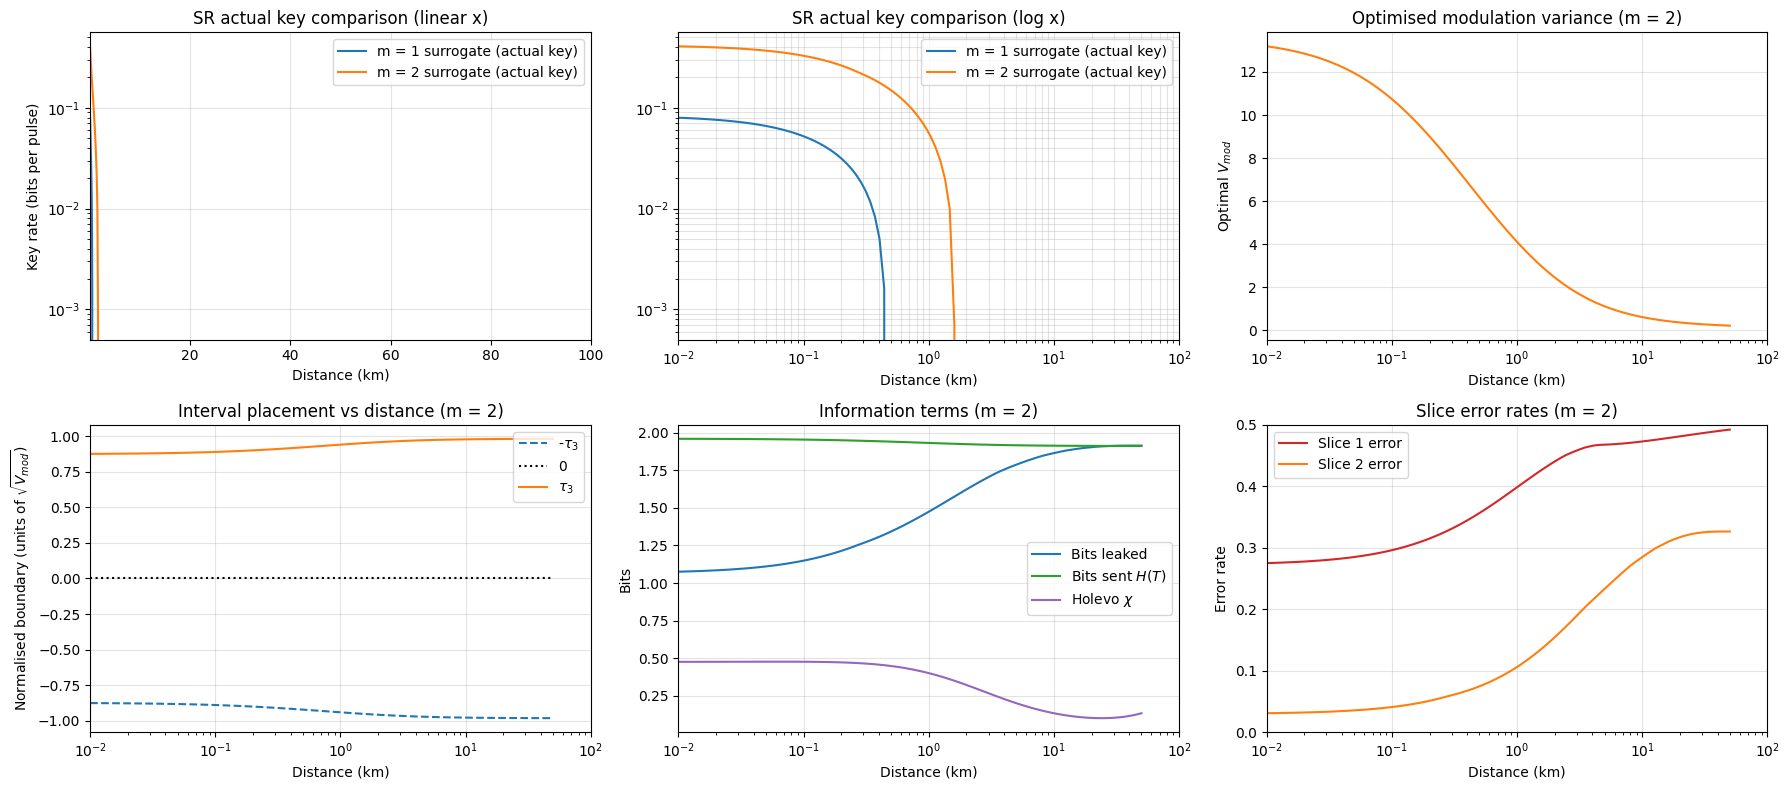

In [65]:
# SR $m = 2$ surrogate optimisation

log_v_bounds = (np.log(v_mod_bounds[0]), np.log(v_mod_bounds[1]))
u_bounds = (0.15, 3.0)

surrogate_m2_vmods = []
surrogate_m2_us = []
surrogate_m2_surrogate_rates = []
surrogate_m2_actual_key_rates = []
surrogate_m2_mutual_infos = []
surrogate_m2_quant_entropies = []
surrogate_m2_conditional_entropies = []
surrogate_m2_holevo = []
surrogate_m2_bits_sent = []
surrogate_m2_bits_leaked = []
surrogate_m2_etas = []
surrogate_m2_slice_errors = []
surrogate_m2_excess_noise = []

log_v_guess = float(np.mean(log_v_bounds))
u_guess = 1.0

progress_iter = tqdm(distances_km, desc="SR m=2 surrogate", leave=False)
for distance_km in progress_iter:
    T = fibre_transmittance(distance_km)
    xi_excess = float(excess_noise_from_distance(distance_km))
    surrogate_m2_excess_noise.append(xi_excess)

    def neg_surrogate_rate(params):
        log_v_mod, u_val = params
        v_mod = float(np.exp(log_v_mod))
        tau_arr = [-np.inf, -float(u_val), 0.0, float(u_val), np.inf]
        sr_candidate = SR(
            m=2,
            modulation_variance=v_mod,
            transmittance=float(T),
            excess_noise=xi_excess,
            Delta_QCT=Delta_QCT,
            code_efficiency=eta_c,
        )
        surrogate_rate, *_ = surrogate_key_components(sr_candidate, tau_arr)
        return -surrogate_rate

    result = minimize(
        neg_surrogate_rate,
        x0=[log_v_guess, u_guess],
        bounds=[log_v_bounds, u_bounds],
        method="L-BFGS-B",
        options={"maxiter": 200, "gtol": 1e-06, "maxls": 50},
    )
    if not result.success:
        raise RuntimeError(
            f"Surrogate optimisation (m=2) failed at distance {distance_km} km: {result.message}"
        )

    log_v_opt, u_opt = result.x
    v_opt = float(np.exp(log_v_opt))
    tau_opt = [-np.inf, -float(u_opt), 0.0, float(u_opt), np.inf]

    log_v_guess, u_guess = float(log_v_opt), float(u_opt)

    sr_opt = SR(
        m=2,
        modulation_variance=v_opt,
        transmittance=float(T),
        excess_noise=xi_excess,
        Delta_QCT=Delta_QCT,
        code_efficiency=eta_c,
    )

    surrogate_rate, mutual_info, quant_entropy, cond_entropy, holevo = surrogate_key_components(sr_opt, tau_opt)
    metrics = sr_opt.evaluate_reconciliation_efficiency(tau_opt)

    surrogate_m2_vmods.append(v_opt)
    surrogate_m2_us.append(float(u_opt))
    surrogate_m2_surrogate_rates.append(surrogate_rate)
    surrogate_m2_actual_key_rates.append(metrics["key_rate"])
    surrogate_m2_mutual_infos.append(mutual_info)
    surrogate_m2_quant_entropies.append(quant_entropy)
    surrogate_m2_conditional_entropies.append(cond_entropy)
    surrogate_m2_holevo.append(holevo)
    surrogate_m2_bits_sent.append(metrics["bits_sent"])
    surrogate_m2_bits_leaked.append(metrics["bits_leaked"])
    surrogate_m2_etas.append(metrics["eta"])
    surrogate_m2_slice_errors.append([slice_info["error_rate"] for slice_info in metrics["slices"]])

surrogate_m2_vmods = np.array(surrogate_m2_vmods)
surrogate_m2_us = np.array(surrogate_m2_us)
surrogate_m2_surrogate_rates = np.array(surrogate_m2_surrogate_rates)
surrogate_m2_actual_key_rates = np.array(surrogate_m2_actual_key_rates)
surrogate_m2_mutual_infos = np.array(surrogate_m2_mutual_infos)
surrogate_m2_quant_entropies = np.array(surrogate_m2_quant_entropies)
surrogate_m2_conditional_entropies = np.array(surrogate_m2_conditional_entropies)
surrogate_m2_holevo = np.array(surrogate_m2_holevo)
surrogate_m2_bits_sent = np.array(surrogate_m2_bits_sent)
surrogate_m2_bits_leaked = np.array(surrogate_m2_bits_leaked)
surrogate_m2_etas = np.array(surrogate_m2_etas)
surrogate_m2_slice_errors = np.array(surrogate_m2_slice_errors)
surrogate_m2_excess_noise = np.array(surrogate_m2_excess_noise)

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
(ax_key_lin, ax_key_log, ax_vmod), (ax_tau, ax_bits, ax_errors) = axes

ax_key_lin.plot(distances_km, surrogate_m1_actual_key_rates, label='m = 1 surrogate (actual key)', color='tab:blue')
# ax_key_lin.plot(distances_km, true_m1_key_rates, label='m = 1 actual @ true opt', color='tab:blue', linestyle=':', alpha=0.6)
ax_key_lin.plot(distances_km, surrogate_m2_actual_key_rates, label='m = 2 surrogate (actual key)', color='tab:orange')
ax_key_lin.set_xlabel('Distance (km)')
ax_key_lin.set_ylabel('Key rate (bits per pulse)')
ax_key_lin.set_title('SR actual key comparison (linear x)')
ax_key_lin.set_yscale('log')
ax_key_lin.set_xlim(1e-2, 1e2)
ax_key_lin.grid(True, alpha=0.35)
ax_key_lin.legend()

ax_key_log.plot(distances_km, surrogate_m1_actual_key_rates, label='m = 1 surrogate (actual key)', color='tab:blue')
# ax_key_log.plot(distances_km, true_m1_key_rates, label='m = 1 actual @ true opt', color='tab:blue', linestyle=':', alpha=0.6)
ax_key_log.plot(distances_km, surrogate_m2_actual_key_rates, label='m = 2 surrogate (actual key)', color='tab:orange')
ax_key_log.set_xlabel('Distance (km)')
ax_key_log.set_title('SR actual key comparison (log x)')
ax_key_log.set_yscale('log')
ax_key_log.set_xscale('log')
ax_key_log.set_xlim(1e-2, 1e2)
ax_key_log.grid(True, which='both', alpha=0.35)
ax_key_log.legend()

ax_vmod.plot(distances_km, surrogate_m2_vmods, color='tab:orange')
ax_vmod.set_xlabel('Distance (km)')
ax_vmod.set_ylabel('Optimal $V_{mod}$')
ax_vmod.set_title('Optimised modulation variance (m = 2)')
ax_vmod.set_xscale('log')
ax_vmod.set_xlim(1e-2, 1e2)
ax_vmod.grid(True, alpha=0.35)

ax_tau.plot(distances_km, -surrogate_m2_us, linestyle='--', label='-$\\tau_3$')
ax_tau.plot(distances_km, np.zeros_like(surrogate_m2_us), linestyle=':', color='black', label='0')
ax_tau.plot(distances_km, surrogate_m2_us, label='$\\tau_3$')
ax_tau.set_xlabel('Distance (km)')
ax_tau.set_ylabel('Normalised boundary (units of $\\sqrt{V_{mod}}$)')
ax_tau.set_title('Interval placement vs distance (m = 2)')
ax_tau.set_xscale('log')
ax_tau.set_xlim(1e-2, 1e2)
ax_tau.grid(True, alpha=0.35)
ax_tau.legend()

ax_bits.plot(distances_km, surrogate_m2_bits_leaked, color='tab:blue', label='Bits leaked')
ax_bits.plot(distances_km, surrogate_m2_bits_sent, color='tab:green', label='Bits sent $H(T)$')
ax_bits.plot(distances_km, surrogate_m2_holevo, color='tab:purple', label='Holevo $\\chi$')
ax_bits.set_xlabel('Distance (km)')
ax_bits.set_ylabel('Bits')
ax_bits.set_title('Information terms (m = 2)')
ax_bits.set_xscale('log')
ax_bits.set_xlim(1e-2, 1e2)
ax_bits.grid(True, alpha=0.35)
ax_bits.legend()

ax_errors.plot(distances_km, surrogate_m2_slice_errors[:, 0], color='tab:red', label='Slice 1 error')
ax_errors.plot(distances_km, surrogate_m2_slice_errors[:, 1], color='tab:orange', label='Slice 2 error')
ax_errors.set_xlabel('Distance (km)')
ax_errors.set_ylabel('Error rate')
ax_errors.set_title('Slice error rates (m = 2)')
ax_errors.set_xscale('log')
ax_errors.set_xlim(1e-2, 1e2)
ax_errors.set_ylim(0.0, 0.5)
ax_errors.grid(True, alpha=0.35)
ax_errors.legend()

fig.tight_layout()

### SR $m = 3$

SR m=3 surrogate:   0%|          | 0/100 [00:00<?, ?it/s]

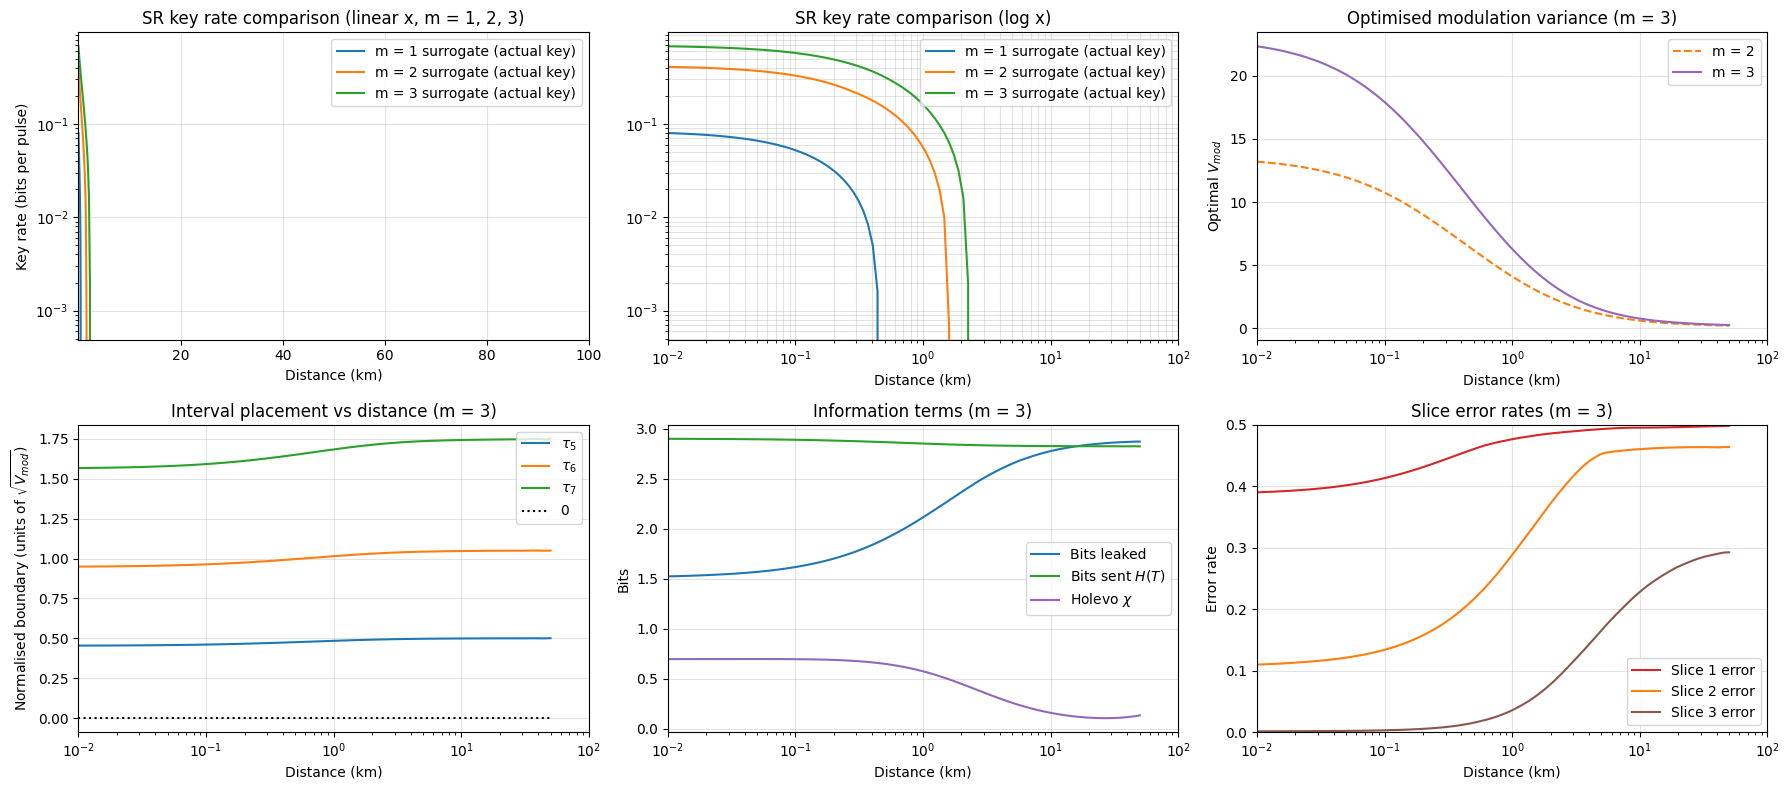

In [66]:
# SR $m = 3$ surrogate optimisation
log_increment_bounds = (np.log(0.05), np.log(5.0))

def build_symmetric_tau(log_increments):
    increments = np.exp(log_increments)
    positives = np.cumsum(increments)
    return np.concatenate(([-np.inf], -positives[::-1], [0.0], positives, [np.inf]))

surrogate_m3_vmods = []
surrogate_m3_positive_edges = []
surrogate_m3_surrogate_rates = []
surrogate_m3_actual_key_rates = []
surrogate_m3_mutual_infos = []
surrogate_m3_quant_entropies = []
surrogate_m3_conditional_entropies = []
surrogate_m3_holevo = []
surrogate_m3_bits_sent = []
surrogate_m3_bits_leaked = []
surrogate_m3_etas = []
surrogate_m3_slice_errors = []
surrogate_m3_excess_noise = []

log_v_guess = float(np.mean(log_v_bounds))
increment_log_guess = np.log(np.array([0.4, 0.35, 0.3]))

progress_iter = tqdm(distances_km, desc="SR m=3 surrogate", leave=False)
for distance_km in progress_iter:
    T = fibre_transmittance(distance_km)
    xi_excess = float(excess_noise_from_distance(distance_km))
    surrogate_m3_excess_noise.append(xi_excess)

    def neg_surrogate_rate(params):
        log_v_mod = params[0]
        log_increments = params[1:]
        v_mod = float(np.exp(log_v_mod))
        tau_arr = build_symmetric_tau(log_increments)
        sr_candidate = SR(
            m=3,
            modulation_variance=v_mod,
            transmittance=float(T),
            excess_noise=xi_excess,
            Delta_QCT=Delta_QCT,
            code_efficiency=eta_c,
        )
        surrogate_rate, *_ = surrogate_key_components(sr_candidate, tau_arr)
        return -surrogate_rate

    bounds = [log_v_bounds] + [log_increment_bounds] * 3

    result = minimize(
        neg_surrogate_rate,
        x0=np.concatenate(([log_v_guess], increment_log_guess)),
        bounds=bounds,
        method="L-BFGS-B",
        options={"maxiter": 200, "gtol": 1e-06, "maxls": 50},
    )
    if not result.success:
        raise RuntimeError(
            f"Surrogate optimisation (m=3) failed at distance {distance_km} km: {result.message}"
        )

    log_v_opt = float(result.x[0])
    log_increments_opt = np.asarray(result.x[1:], dtype=float)
    v_opt = float(np.exp(log_v_opt))
    tau_opt = build_symmetric_tau(log_increments_opt)
    positive_edges = tau_opt[5:8]

    log_v_guess = log_v_opt
    increments = np.diff(np.concatenate(([0.0], positive_edges)))
    increment_log_guess = np.log(np.clip(increments, np.exp(log_increment_bounds[0]), None))
    increment_log_guess = np.clip(
        increment_log_guess,
        log_increment_bounds[0] + 1e-6,
        log_increment_bounds[1] - 1e-6,
    )

    sr_opt = SR(
        m=3,
        modulation_variance=v_opt,
        transmittance=float(T),
        excess_noise=xi_excess,
        Delta_QCT=Delta_QCT,
        code_efficiency=eta_c,
    )

    surrogate_rate, mutual_info, quant_entropy, cond_entropy, holevo = surrogate_key_components(sr_opt, tau_opt)
    metrics = sr_opt.evaluate_reconciliation_efficiency(tau_opt)

    surrogate_m3_vmods.append(v_opt)
    surrogate_m3_positive_edges.append(positive_edges)
    surrogate_m3_surrogate_rates.append(surrogate_rate)
    surrogate_m3_actual_key_rates.append(metrics["key_rate"])
    surrogate_m3_mutual_infos.append(mutual_info)
    surrogate_m3_quant_entropies.append(quant_entropy)
    surrogate_m3_conditional_entropies.append(cond_entropy)
    surrogate_m3_holevo.append(holevo)
    surrogate_m3_bits_sent.append(metrics["bits_sent"])
    surrogate_m3_bits_leaked.append(metrics["bits_leaked"])
    surrogate_m3_etas.append(metrics["eta"])
    surrogate_m3_slice_errors.append([slice_info["error_rate"] for slice_info in metrics["slices"]])

surrogate_m3_vmods = np.array(surrogate_m3_vmods)
surrogate_m3_positive_edges = np.array(surrogate_m3_positive_edges)
surrogate_m3_surrogate_rates = np.array(surrogate_m3_surrogate_rates)
surrogate_m3_actual_key_rates = np.array(surrogate_m3_actual_key_rates)
surrogate_m3_mutual_infos = np.array(surrogate_m3_mutual_infos)
surrogate_m3_quant_entropies = np.array(surrogate_m3_quant_entropies)
surrogate_m3_conditional_entropies = np.array(surrogate_m3_conditional_entropies)
surrogate_m3_holevo = np.array(surrogate_m3_holevo)
surrogate_m3_bits_sent = np.array(surrogate_m3_bits_sent)
surrogate_m3_bits_leaked = np.array(surrogate_m3_bits_leaked)
surrogate_m3_etas = np.array(surrogate_m3_etas)
surrogate_m3_slice_errors = np.array(surrogate_m3_slice_errors)
surrogate_m3_excess_noise = np.array(surrogate_m3_excess_noise)

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
(ax_key_lin, ax_key_log, ax_vmod), (ax_tau, ax_bits, ax_errors) = axes

ax_key_lin.plot(distances_km, surrogate_m1_actual_key_rates, label='m = 1 surrogate (actual key)')
ax_key_lin.plot(distances_km, surrogate_m2_actual_key_rates, label='m = 2 surrogate (actual key)', linestyle='-')
ax_key_lin.plot(distances_km, surrogate_m3_actual_key_rates, label='m = 3 surrogate (actual key)', linestyle='-')
ax_key_lin.set_xlabel('Distance (km)')
ax_key_lin.set_ylabel('Key rate (bits per pulse)')
ax_key_lin.set_title('SR key rate comparison (linear x, m = 1, 2, 3)')
ax_key_lin.set_yscale('log')
ax_key_lin.set_xlim(1e-2, 1e2)
ax_key_lin.grid(True, alpha=0.35)
ax_key_lin.legend()

ax_key_log.plot(distances_km, surrogate_m1_actual_key_rates, label='m = 1 surrogate (actual key)')
ax_key_log.plot(distances_km, surrogate_m2_actual_key_rates, label='m = 2 surrogate (actual key)', linestyle='-')
ax_key_log.plot(distances_km, surrogate_m3_actual_key_rates, label='m = 3 surrogate (actual key)', linestyle='-')
ax_key_log.set_xlabel('Distance (km)')
ax_key_log.set_title('SR key rate comparison (log x)')
ax_key_log.set_yscale('log')
ax_key_log.set_xscale('log')
ax_key_log.set_xlim(1e-2, 1e2)
ax_key_log.grid(True, which='both', alpha=0.35)
ax_key_log.legend()

ax_vmod.plot(distances_km, surrogate_m2_vmods, color='tab:orange', linestyle='--', label='m = 2')
ax_vmod.plot(distances_km, surrogate_m3_vmods, color='tab:purple', label='m = 3')
ax_vmod.set_xlabel('Distance (km)')
ax_vmod.set_ylabel('Optimal $V_{mod}$')
ax_vmod.set_title('Optimised modulation variance (m = 3)')
ax_vmod.set_xscale('log')
ax_vmod.set_xlim(1e-2, 1e2)
ax_vmod.grid(True, alpha=0.35)
ax_vmod.legend()

ax_tau.plot(distances_km, surrogate_m3_positive_edges[:, 0], label='$\\tau_5$')
ax_tau.plot(distances_km, surrogate_m3_positive_edges[:, 1], label='$\\tau_6$')
ax_tau.plot(distances_km, surrogate_m3_positive_edges[:, 2], label='$\\tau_7$')
ax_tau.plot(distances_km, np.zeros_like(distances_km), linestyle=':', color='black', label='0')
ax_tau.set_xlabel('Distance (km)')
ax_tau.set_ylabel('Normalised boundary (units of $\\sqrt{V_{mod}}$)')
ax_tau.set_title('Interval placement vs distance (m = 3)')
ax_tau.set_xscale('log')
ax_tau.set_xlim(1e-2, 1e2)
ax_tau.grid(True, alpha=0.35)
ax_tau.legend()

ax_bits.plot(distances_km, surrogate_m3_bits_leaked, color='tab:blue', label='Bits leaked')
ax_bits.plot(distances_km, surrogate_m3_bits_sent, color='tab:green', label='Bits sent $H(T)$')
ax_bits.plot(distances_km, surrogate_m3_holevo, color='tab:purple', label='Holevo $\\chi$')
ax_bits.set_xlabel('Distance (km)')
ax_bits.set_ylabel('Bits')
ax_bits.set_title('Information terms (m = 3)')
ax_bits.set_xscale('log')
ax_bits.set_xlim(1e-2, 1e2)
ax_bits.grid(True, alpha=0.35)
ax_bits.legend()

ax_errors.plot(distances_km, surrogate_m3_slice_errors[:, 0], color='tab:red', label='Slice 1 error')
ax_errors.plot(distances_km, surrogate_m3_slice_errors[:, 1], color='tab:orange', label='Slice 2 error')
ax_errors.plot(distances_km, surrogate_m3_slice_errors[:, 2], color='tab:brown', label='Slice 3 error')
ax_errors.set_xlabel('Distance (km)')
ax_errors.set_ylabel('Error rate')
ax_errors.set_title('Slice error rates (m = 3)')
ax_errors.set_xscale('log')
ax_errors.set_xlim(1e-2, 1e2)
ax_errors.set_ylim(0.0, 0.5)
ax_errors.grid(True, alpha=0.35)
ax_errors.legend()

fig.tight_layout()

### Comparing Surrogate and Actual Key Rates for SR $m = 1, 2, 3$

Clarifying terminology used below:

- Surrogate key ("surrogate objective"): $K_{\text{sur}} = I(T;Y) - \chi$ (or $p_{\text{pass}}(I-\chi)$ in guarded cases). This is the *optimisation* objective (smooth, no hard-min).
- Actual key ("actual"): The full key rate produced by the reconciliation efficiency / leakage machinery (with the slice error rates and hard-min effects inside its computation).

Status of each plotted curve:

- $m=1$ actual @ true optimum: Optimised directly on the actual key (since with one slice it is smooth/stable enough).
- $m=1$ actual @ surrogate optimum: Actual key evaluated at the parameters that maximise the surrogate objective (lets us see surrogate-vs-true discrepancy for the simplest case).
- $m=2,3$ actual @ surrogate optimum: Actual key evaluated **only** at the surrogate-optimal parameters (we have **not** yet directly re-optimised the actual key for these higher $m$ in this notebook).

Reading the plots:

- Solid lines (actual) vs dashed lines (either surrogate objective or actual-at-surrogate-opt) make the provenance explicit.
- Differences between the two $m=1$ actual curves show the surrogate-induced parameter shift; if they coincide closely the surrogate optimum is near the true optimum for that metric.
- Any performance gap for $m=2,3$ relative to $m=1$ should be interpreted as a *lower bound* on what could be achieved after a dedicated (possibly non-smooth) actual-key optimisation.

Legend notation:

- "actual @ true opt" = maximised with respect to the actual key.
- "actual @ sur opt" = evaluated at the surrogate-optimal parameters.
- "surrogate objective" = the $I-\chi$ objective value at its optimum.

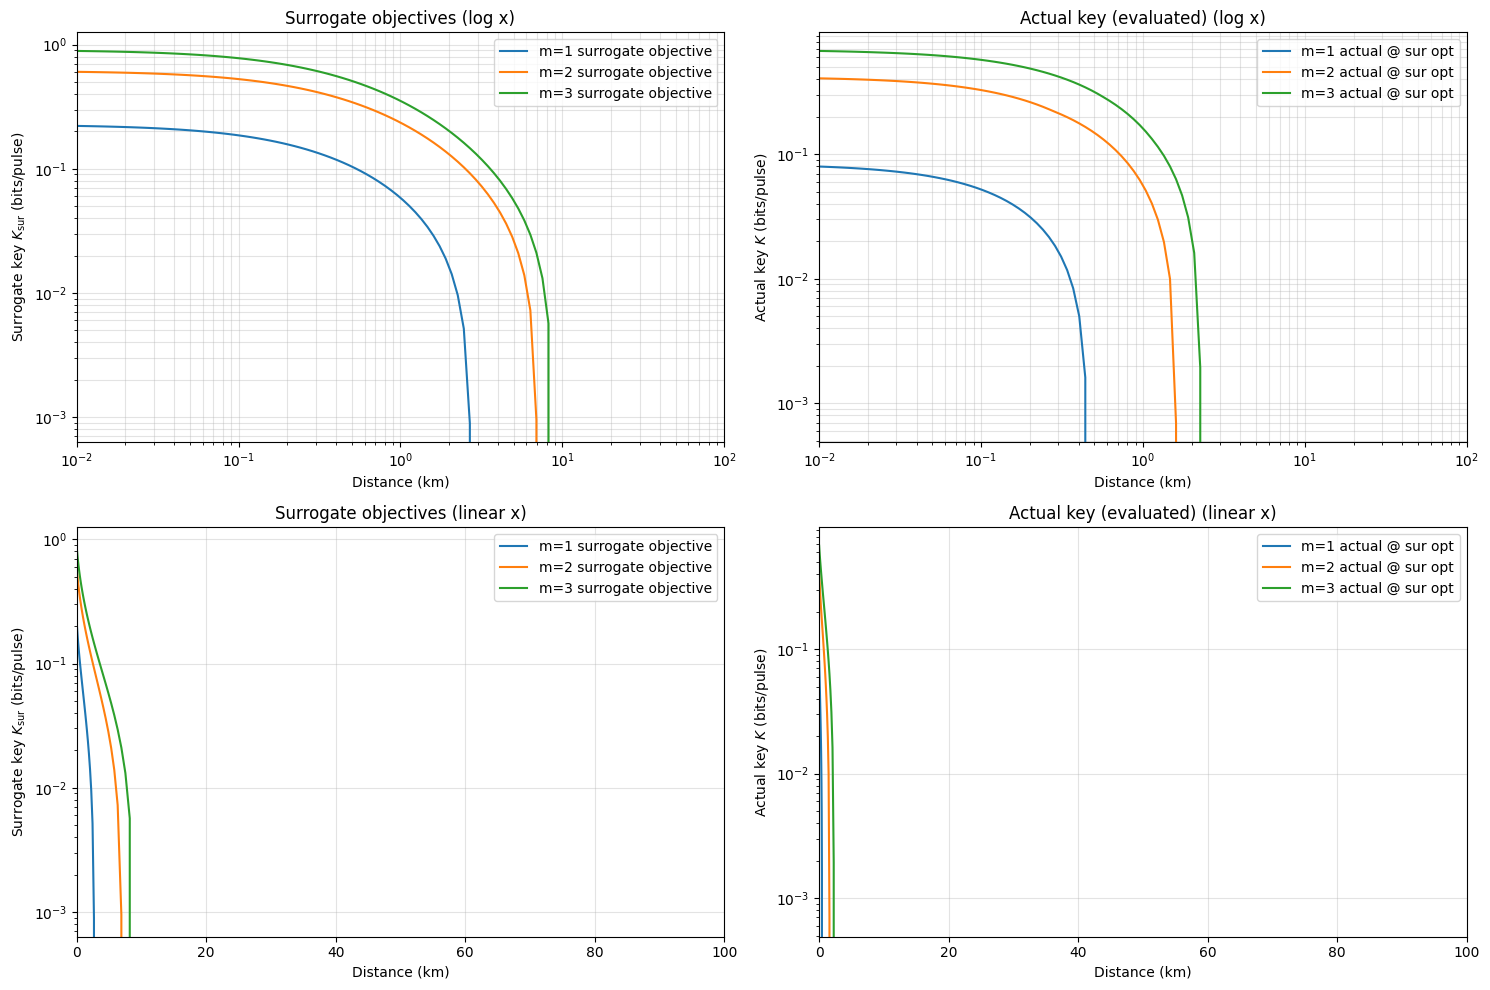

In [67]:
# Compare surrogate vs actual key rates for m = 1, 2, 3 with clearer provenance
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
(ax_surrogate_log, ax_actual_log), (ax_surrogate_lin, ax_actual_lin) = axes

# --- Surrogate objective curves (log x) ---
ax_surrogate_log.plot(distances_km, surrogate_surrogate_rates, label='m=1 surrogate objective', color='tab:blue')
ax_surrogate_log.plot(distances_km, surrogate_m2_surrogate_rates, label='m=2 surrogate objective', color='tab:orange')
ax_surrogate_log.plot(distances_km, surrogate_m3_surrogate_rates, label='m=3 surrogate objective', color='tab:green')
ax_surrogate_log.set_xlabel('Distance (km)')
ax_surrogate_log.set_ylabel('Surrogate key $K_{\\text{sur}}$ (bits/pulse)')
ax_surrogate_log.set_title('Surrogate objectives (log x)')
ax_surrogate_log.set_yscale('log')
ax_surrogate_log.set_xscale('log')
ax_surrogate_log.set_xlim(1e-2, 1e2)
ax_surrogate_log.grid(True, which='both', alpha=0.35)
ax_surrogate_log.legend()

# --- Actual curves (log x) ---
ax_actual_log.plot(distances_km, surrogate_m1_actual_key_rates, label='m=1 actual @ sur opt', color='tab:blue')
ax_actual_log.plot(distances_km, surrogate_m2_actual_key_rates, label='m=2 actual @ sur opt', color='tab:orange')
ax_actual_log.plot(distances_km, surrogate_m3_actual_key_rates, label='m=3 actual @ sur opt', color='tab:green')
ax_actual_log.set_xlabel('Distance (km)')
ax_actual_log.set_ylabel('Actual key $K$ (bits/pulse)')
ax_actual_log.set_title('Actual key (evaluated) (log x)')
ax_actual_log.set_yscale('log')
ax_actual_log.set_xscale('log')
ax_actual_log.set_xlim(1e-2, 1e2)
ax_actual_log.grid(True, which='both', alpha=0.35)
ax_actual_log.legend()

# --- Surrogate objective curves (linear x) ---
ax_surrogate_lin.plot(distances_km, surrogate_surrogate_rates, label='m=1 surrogate objective', color='tab:blue')
ax_surrogate_lin.plot(distances_km, surrogate_m2_surrogate_rates, label='m=2 surrogate objective', color='tab:orange')
ax_surrogate_lin.plot(distances_km, surrogate_m3_surrogate_rates, label='m=3 surrogate objective', color='tab:green')
ax_surrogate_lin.set_xlabel('Distance (km)')
ax_surrogate_lin.set_ylabel('Surrogate key $K_{\\text{sur}}$ (bits/pulse)')
ax_surrogate_lin.set_title('Surrogate objectives (linear x)')
ax_surrogate_lin.set_yscale('log')
ax_surrogate_lin.set_xlim(0, 100)
ax_surrogate_lin.grid(True, alpha=0.35)
ax_surrogate_lin.legend()

# --- Actual curves (linear x) ---
ax_actual_lin.plot(distances_km, surrogate_m1_actual_key_rates, label='m=1 actual @ sur opt', color='tab:blue')
ax_actual_lin.plot(distances_km, surrogate_m2_actual_key_rates, label='m=2 actual @ sur opt', color='tab:orange')
ax_actual_lin.plot(distances_km, surrogate_m3_actual_key_rates, label='m=3 actual @ sur opt', color='tab:green')
ax_actual_lin.set_xlabel('Distance (km)')
ax_actual_lin.set_ylabel('Actual key $K$ (bits/pulse)')
ax_actual_lin.set_title('Actual key (evaluated) (linear x)')
ax_actual_lin.set_yscale('log')
ax_actual_lin.set_xlim(0, 100)
ax_actual_lin.grid(True, alpha=0.35)
ax_actual_lin.legend()

fig.tight_layout()

### Placeholder for Paper

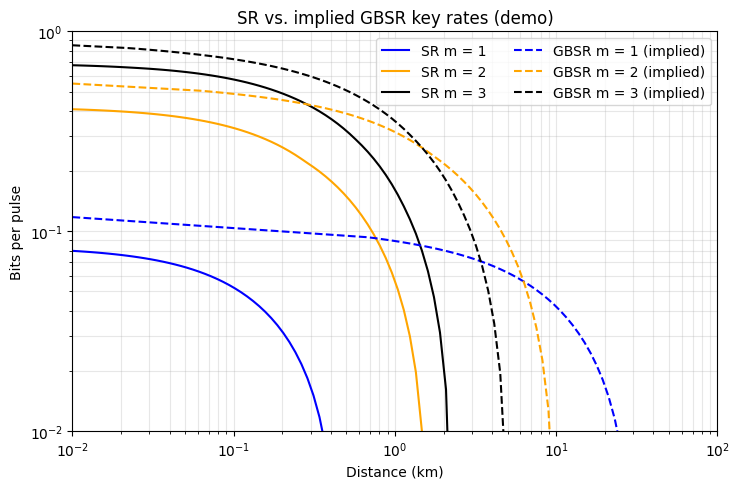

In [83]:
import numpy as np
import matplotlib.pyplot as plt

# --- tiny helpers ---
def cutoff_km(distances, y, eps=1e-12):
    idx = np.where(y > eps)[0]
    return distances[idx[-1]] if len(idx) else distances[0]

def stretch_in_distance(sr_curve, distances, scale):
    x = distances / scale
    y = np.interp(x, distances, sr_curve, left=sr_curve[0], right=0.0)
    y[y <= 0] = np.nan  # log-safe
    return y

def pow_tilt(distances, alpha, d_ref=0.05):
    # Gentle slope on a log-x plot; alpha ~ 0.03–0.07
    return (distances / d_ref) ** (-alpha)

# --- 1) solid SR cutoffs ---
d1 = cutoff_km(distances_km, surrogate_m1_actual_key_rates)
d2 = cutoff_km(distances_km, surrogate_m2_actual_key_rates)
d3 = cutoff_km(distances_km, surrogate_m3_actual_key_rates)

# --- 2) choose dashed fall-off locations (km): reversed order m1 > m2 > m3 ---
fall_m1 = 30.0
fall_m2 = 10.0
fall_m3 = 5.0

# --- 3) horizontal scales to hit those fall-offs ---
s1, s2, s3 = fall_m1/d1, fall_m2/d2, fall_m3/d3

# --- 4) stretched SR (sets the cliff positions) ---
sr1_st = stretch_in_distance(surrogate_m1_actual_key_rates, distances_km, s1)
sr2_st = stretch_in_distance(surrogate_m2_actual_key_rates, distances_km, s2)
sr3_st = stretch_in_distance(surrogate_m3_actual_key_rates, distances_km, s3)

# --- 5) simple vertical gains + tiny power-law tilt for early downhill slope ---
gain1, gain2, gain3 = 1.35, 1.25, 1.18   # constant lifts; tweak to taste
alpha1, alpha2, alpha3 = 0.055, 0.045, 0.040  # larger alpha = more early slope
d_ref = 0.05  # km; pivot point for the tilt

tilt1 = pow_tilt(distances_km, alpha1, d_ref)
tilt2 = pow_tilt(distances_km, alpha2, d_ref)
tilt3 = pow_tilt(distances_km, alpha3, d_ref)

implied_gbsr_m1 = sr1_st * gain1 * tilt1
implied_gbsr_m2 = sr2_st * gain2 * tilt2
implied_gbsr_m3 = sr3_st * gain3 * tilt3

# --- plot ---
fig, ax = plt.subplots(figsize=(7.5, 5.0))
ax.plot(distances_km, surrogate_m1_actual_key_rates, label="SR m = 1", color="blue")
ax.plot(distances_km, surrogate_m2_actual_key_rates, label="SR m = 2", color="orange")
ax.plot(distances_km, surrogate_m3_actual_key_rates, label="SR m = 3", color="black")

ax.plot(distances_km, implied_gbsr_m1, "--", color="blue",   label="GBSR m = 1 (implied)")
ax.plot(distances_km, implied_gbsr_m2, "--", color="orange", label="GBSR m = 2 (implied)")
ax.plot(distances_km, implied_gbsr_m3, "--", color="black",  label="GBSR m = 3 (implied)")

ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Distance (km)"); ax.set_ylabel("Bits per pulse")
ax.set_title("SR vs. implied GBSR key rates (demo)")
ax.set_ylim(1e-2, 1e0); ax.set_xlim(1e-2, 1e2)
ax.grid(True, which="both", alpha=0.3); ax.legend(ncol=2)
fig.tight_layout()


In [84]:
"""Export SR and implied GBSR key rate traces used in the figure above."""
export_columns = {
    "distance_km": distances_km,
    "sr_m1_key": surrogate_m1_actual_key_rates,
    "sr_m2_key": surrogate_m2_actual_key_rates,
    "sr_m3_key": surrogate_m3_actual_key_rates,
    "gbsr_m1_implied": implied_gbsr_m1,
    "gbsr_m2_implied": implied_gbsr_m2,
    "gbsr_m3_implied": implied_gbsr_m3,
}

export_array = np.column_stack([export_columns[key] for key in export_columns])
header = ",".join(export_columns.keys())
np.savetxt(
    "key_effs_for_paper.csv",
    export_array,
    delimiter=",",
    header=header,
    comments="",
    fmt="%.6f",
)

## GBSR

As discussed, the optimistion problem for GBSR is VERY hard, with varying branches etc. So, to move forward, we will adopt the following strategy:
- Use $V_\text{mod}$, $\mathbf{\tau}$ found for a SR at the given $m$
- Do the 'actual' optimisation $K = p_\text{pass}(H(T(X);Y_\text{PS}) - \sum_i \big(1-\eta_{c,i}(1-h_2(e_i\mid A=1))\big) - \chi)$
- Note that this should involve just the 1-D quadrature integrals to find $e$ (should be implemented already for a Gray code in GBSR)

### GBSR $m=1$

In this case, we now need to only optimise $g_{+,1}$, as we get $g_{-,1}$ by symmetry and $V_\text{mod}$ we get from the surrogate optimisation result


In [69]:
# """Optimise GBSR $m=1$ guard width using $K = p_{pass}[H(T)-\ell-\chi]$."""
# # GBSR m = 1 guard-band optimisation (actual key objective)
# log_guard_bounds = (np.log(1e-4), np.log(5.0))
# log_guard_guess = np.log(0.05)

# gbsr_tau_m1 = tau_sr_m1  # reuse the SR bin edges

# # Containers for optimisation results
# gbsr_m1_vmods = np.asarray(true_m1_vmods, dtype=float)
# gbsr_m1_guard_widths = []
# gbsr_m1_guard_edges_positive = []
# gbsr_m1_guard_edges_negative = []
# gbsr_m1_key_rates = []
# gbsr_m1_surrogate_rates = []
# gbsr_m1_bits_sent = []
# gbsr_m1_bits_leaked = []
# gbsr_m1_pass_probabilities = []
# gbsr_m1_raw_error_rates = []
# gbsr_m1_error_rates = []
# gbsr_m1_etas = []
# gbsr_m1_holevo = []
# gbsr_m1_excess_noise = []

# def build_guard_array(guard_width: float) -> list[list[float]]:
#     """Return the symmetric guard array for m=1 with a single central band."""
#     guard_width = float(guard_width)
#     return [
#         [0.0, 0.0],              # tau_0 = -inf boundary (no guard)
#         [guard_width, guard_width],  # central boundary at tau_1 = 0
#         [0.0, 0.0],              # tau_2 = +inf boundary (no guard)
#     ]

# progress_iter = tqdm(range(len(distances_km)), desc="GBSR m=1 actual", leave=False)
# for idx in progress_iter:
#     distance_km = float(distances_km[idx])
#     v_mod = float(gbsr_m1_vmods[idx])

#     T = fibre_transmittance(distance_km)
#     xi_excess = float(excess_noise_from_distance(distance_km))
#     gbsr_m1_excess_noise.append(xi_excess)

#     gbsr_candidate = GBSR(
#         m=1,
#         modulation_variance=v_mod,
#         transmittance=float(T),
#         excess_noise=xi_excess,
#         Delta_QCT=Delta_QCT,
#         code_efficiency=eta_c,
#     )
#     holevo_term = gbsr_candidate._holevo_with_qct()

#     def neg_actual_key(log_guard_width: float) -> float:
#         guard_width = float(np.exp(log_guard_width))
#         guard_arr = build_guard_array(guard_width)
#         metrics = gbsr_candidate.evaluate_reconciliation_efficiency(
#             gbsr_tau_m1,
#             guard_arr,
#             bit_assignment="Gray",
#         )
#         p_pass = metrics["p_pass"]
#         h_t = metrics["quantisation_entropy"]
#         leak_per_bit = metrics["leak_per_bit"]
#         return -p_pass * (h_t - leak_per_bit - holevo_term)

#     result = minimize_scalar(neg_actual_key, bounds=log_guard_bounds, method="bounded")
#     if not result.success:
#         raise RuntimeError(
#             f"Guard-band optimisation failed at distance {distance_km:.3f} km: {result.message}"
#         )

#     log_guard_opt = float(result.x)
#     log_guard_guess = log_guard_opt  # warm start for the next distance
#     guard_opt = float(np.exp(log_guard_opt))
#     guard_arr_opt = build_guard_array(guard_opt)

#     metrics_opt = gbsr_candidate.evaluate_reconciliation_efficiency(
#         gbsr_tau_m1,
#         guard_arr_opt,
#         bit_assignment="Gray",
#     )

#     p_pass_opt = metrics_opt["p_pass"]
#     h_t_opt = metrics_opt["quantisation_entropy"]
#     leak_per_bit_opt = metrics_opt["leak_per_bit"]
#     key_rate_opt = p_pass_opt * (h_t_opt - leak_per_bit_opt - holevo_term)
#     surrogate_rate_opt = p_pass_opt * (h_t_opt - holevo_term)

#     gbsr_m1_guard_widths.append(guard_opt)
#     gbsr_m1_guard_edges_positive.append(guard_opt)
#     gbsr_m1_guard_edges_negative.append(-guard_opt)

#     gbsr_m1_key_rates.append(key_rate_opt)
#     gbsr_m1_surrogate_rates.append(surrogate_rate_opt)
#     gbsr_m1_bits_sent.append(metrics_opt["bits_sent"])
#     gbsr_m1_bits_leaked.append(metrics_opt["bits_leaked"])
#     gbsr_m1_pass_probabilities.append(p_pass_opt)
#     gbsr_m1_raw_error_rates.append(metrics_opt["raw_error_rate"])
#     gbsr_m1_error_rates.append(metrics_opt["error_rate"])
#     gbsr_m1_etas.append(metrics_opt["eta"])
#     gbsr_m1_holevo.append(holevo_term)

# # Convert to numpy arrays for easier downstream use
# gbsr_m1_guard_widths = np.array(gbsr_m1_guard_widths)
# gbsr_m1_guard_edges_positive = np.array(gbsr_m1_guard_edges_positive)
# gbsr_m1_guard_edges_negative = np.array(gbsr_m1_guard_edges_negative)
# gbsr_m1_key_rates = np.array(gbsr_m1_key_rates)
# gbsr_m1_surrogate_rates = np.array(gbsr_m1_surrogate_rates)
# gbsr_m1_bits_sent = np.array(gbsr_m1_bits_sent)
# gbsr_m1_bits_leaked = np.array(gbsr_m1_bits_leaked)
# gbsr_m1_pass_probabilities = np.array(gbsr_m1_pass_probabilities)
# gbsr_m1_raw_error_rates = np.array(gbsr_m1_raw_error_rates)
# gbsr_m1_error_rates = np.array(gbsr_m1_error_rates)
# gbsr_m1_etas = np.array(gbsr_m1_etas)
# gbsr_m1_holevo = np.array(gbsr_m1_holevo)
# gbsr_m1_excess_noise = np.array(gbsr_m1_excess_noise)

# # Derived quantities for plotting
# numerator_bits = gbsr_m1_bits_sent - gbsr_m1_bits_leaked
# pass_safe = np.clip(gbsr_m1_pass_probabilities, 1e-12, None)
# with np.errstate(divide='ignore', invalid='ignore'):
#     bits_sent_per_accept = np.divide(gbsr_m1_bits_sent, pass_safe)
#     bits_leaked_per_accept = np.divide(gbsr_m1_bits_leaked, pass_safe)
#     numerator_per_accept = np.divide(numerator_bits, pass_safe)
#     holevo_per_accept = np.divide(gbsr_m1_holevo, pass_safe)
#     key_per_accept = np.divide(gbsr_m1_key_rates, pass_safe)

In [70]:

# fig, axes = plt.subplots(1, 4, figsize=(22, 4.5))
# ax_key, ax_pass, ax_guard, ax_bits = axes

# # Key rate vs distance
# ax_key.plot(distances_km, gbsr_m1_key_rates, label='Actual key (optimised guard)', color='tab:blue')
# ax_key.plot(distances_km, gbsr_m1_surrogate_rates, label='Surrogate objective $p_{pass}H(T) - p_{pass}\\chi$', color='tab:orange', linestyle='--')
# ax_key.set_xlabel('Distance (km)')
# ax_key.set_ylabel('Bits per pulse')
# ax_key.set_title('GBSR $m=1$ key metrics')
# ax_key.set_xscale('log')
# ax_key.set_yscale('log')
# ax_key.set_xlim(1e-2, 1e2)
# ax_key.grid(True, which='both', alpha=0.35)
# ax_key.legend()

# # Pass probability (separate axis)
# ax_pass.plot(distances_km, gbsr_m1_pass_probabilities, color='tab:green')
# ax_pass.set_xlabel('Distance (km)')
# ax_pass.set_ylabel('$p_{pass}$')
# ax_pass.set_title('Pass probability')
# ax_pass.set_xscale('log')
# ax_pass.set_xlim(1e-2, 1e2)
# ax_pass.set_ylim(0.0, 1.05)
# ax_pass.grid(True, which='both', alpha=0.35)

# # Guard-band placement (normalised to $\\sigma_B$)
# ax_guard.plot(distances_km, gbsr_m1_guard_edges_positive, label='+ guard', color='tab:red')
# ax_guard.plot(distances_km, gbsr_m1_guard_edges_negative, label='- guard', color='tab:red', linestyle='--')
# ax_guard.set_xlabel('Distance (km)')
# ax_guard.set_ylabel('Guard offset (units of $\\sigma_B$)')
# ax_guard.set_title('Guard-band placement vs distance')
# ax_guard.set_xscale('log')
# ax_guard.set_xlim(1e-2, 1e2)
# ax_guard.grid(True, which='both', alpha=0.35)
# ax_guard.legend(loc='lower left')

# # Information terms per pulse
# ax_bits.plot(distances_km, gbsr_m1_bits_sent, label='$p_{pass} H(T)$', color='tab:blue')
# ax_bits.plot(distances_km, gbsr_m1_bits_leaked, label='$p_{pass} \cdot \text{leak}$', color='tab:orange')
# ax_bits.plot(distances_km, numerator_bits, label='Numerator (sent - leaked)', color='tab:green')
# ax_bits.plot(distances_km, gbsr_m1_holevo * gbsr_m1_pass_probabilities, label='$p_{pass} \\chi$', color='tab:purple')
# # raw Holevo (not multiplied by p_pass)
# ax_bits.plot(distances_km, gbsr_m1_holevo, label='Holevo $\\chi$ (per pulse)', color='tab:cyan', linestyle=':')

# # Plot p_pass on a secondary y-axis so scale differences are visible
# ax_bits_twin = ax_bits.twinx()
# ax_bits_twin.plot(distances_km, gbsr_m1_pass_probabilities, label='$p_{pass}$', color='tab:gray', linestyle='-.')
# ax_bits_twin.set_ylabel('$p_{pass}$')
# ax_bits_twin.set_ylim(0.0, 1.05)

# ax_bits.set_xlabel('Distance (km)')
# ax_bits.set_ylabel('Bits per pulse')
# ax_bits.set_title('Information balance (per pulse)')
# ax_bits.set_xscale('log')
# ax_bits.set_xlim(1e-2, 1e2)
# ax_bits.grid(True, which='both', alpha=0.35)

# # Combine legends from both axes
# lines, labels = ax_bits.get_legend_handles_labels()
# lines2, labels2 = ax_bits_twin.get_legend_handles_labels()
# ax_bits.legend(lines + lines2, labels + labels2, loc='best')

# fig.tight_layout()

# # Information terms per accepted symbol
# fig2, ax_accept = plt.subplots(1, 1, figsize=(6.5, 4.2))
# ax_accept.plot(distances_km, bits_sent_per_accept, label='$H(T)$ per accepted', color='tab:blue')
# ax_accept.plot(distances_km, bits_leaked_per_accept, label='Leak per accepted', color='tab:orange')
# ax_accept.plot(distances_km, numerator_per_accept, label='Numerator per accepted', color='tab:green')
# ax_accept.plot(distances_km, holevo_per_accept, label='$\\chi$ per accepted', color='tab:purple')
# ax_accept.plot(distances_km, key_per_accept, label='Key per accepted', color='tab:red', linestyle='--')
# ax_accept.set_xlabel('Distance (km)')
# ax_accept.set_ylabel('Bits per accepted symbol')
# ax_accept.set_title('Information balance (per accepted symbol)')
# ax_accept.set_xscale('log')
# ax_accept.set_xlim(1e-2, 1e2)
# ax_accept.grid(True, which='both', alpha=0.35)
# ax_accept.legend()

# fig2.tight_layout()

In [71]:
# fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
# (ax_key, ax_guard, ax_bits) = axes

# # Key rate vs distance
# ax_key.plot(distances_km, surrogate_m1_actual_key_rates, label='SR $m=1$ actual key', color='tab:blue')
# ax_key.plot(distances_km, gbsr_m1_key_rates, label='GBSR $m=1$ actual key', color='tab:orange')
# ax_key.set_xlabel('Distance (km)')
# ax_key.set_ylabel('Bits per pulse')
# ax_key.set_title('SR vs GBSR $m=1$ actual key')
# ax_key.set_xscale('log')
# ax_key.set_yscale('log')
# ax_key.set_xlim(1e-2, 1e2)
# ax_key.grid(True, which='both', alpha=0.35)
# ax_key.legend()

# # Guard-band placement (normalised to $\\sigma_B$)
# ax_guard.plot(distances_km, gbsr_m1_guard_edges_positive, label='+ guard', color='tab:red')
# ax_guard.plot(distances_km, gbsr_m1_guard_edges_negative, label='- guard', color='tab:red', linestyle='--')
# ax_guard.set_xlabel('Distance (km)')
# ax_guard.set_ylabel('Guard offset (units of $\\sigma_B$)')
# ax_guard.set_title('GBSR $m=1$ guard-band placement vs distance')
# ax_guard.set_xscale('log')
# ax_guard.set_xlim(1e-2, 1e2)
# ax_guard.grid(True, which='both', alpha=0.35)
# ax_guard.legend()

# # Information terms per pulse
# ax_bits.plot(distances_km, gbsr_m1_bits_sent, label='$p_{pass} H(T)$', color='tab:blue')
# ax_bits.plot(distances_km, gbsr_m1_bits_leaked, label='$p_{pass} \\cdot \\text{leak}$', color='tab:orange')
# ax_bits.plot(distances_km, gbsr_m1_key_rates, label='Actual key', color='tab:red', linestyle='--')
# ax_bits.set_xlabel('Distance (km)')
# ax_bits.set_ylabel('Bits per pulse')
# ax_bits.set_title('GBSR $m=1$ information terms')
# ax_bits.set_xscale('log')
# ax_bits.set_xlim(1e-2, 1e2)
# ax_bits.grid(True, which='both', alpha=0.35)
# ax_bits.legend()

# fig.tight_layout()


### GBSR $m = 2$

Now, we perform the same optimisation for $m=2$. Here, we already have $V_\text{mod}$ and $\mathbf{\tau}$ from the SR surrogate optimisation, so we only need to optimise the $g_{\pm,i}$ parameters. Of these, we have

In [72]:
# """Visualise the symmetric guard-band layout for m = 2 with equiprobable bins."""
# from scipy.stats import norm

# # Pick a representative distance (mid-point of our sampled grid)
# distance_index_demo = len(distances_km) // 2
# distance_demo_km = float(distances_km[distance_index_demo])

# # Use the surrogate-optimised modulation variance for this distance
# v_mod_demo = float(surrogate_m2_vmods[distance_index_demo])
# T_demo = fibre_transmittance(distance_demo_km)
# xi_demo = float(excess_noise_from_distance(distance_demo_km))

# # Instantiate a GBSR model for m = 2 at this operating point
# gbsr_demo = GBSR(
#     m=2,
#     modulation_variance=v_mod_demo,
#     transmittance=float(T_demo),
#     excess_noise=xi_demo,
#     Delta_QCT=Delta_QCT,
#     code_efficiency=eta_c,
# )

# # Equiprobable tau spacings under Bob's marginal (normalised to sigma_B)
# interval_probabilities = np.linspace(0.0, 1.0, gbsr_demo.number_of_intervals + 1)
# internal_probs = interval_probabilities[1:-1]
# tau_equiprobable = [-np.inf, *norm.ppf(internal_probs).tolist(), np.inf]

# # Uniform guard widths (normalised) with 0.05 everywhere except the outer boundaries
# guard_width = 0.05
# guard_template = np.full((len(tau_equiprobable), 2), guard_width)
# guard_template[0] = (0.0, 0.0)
# guard_template[-1] = (0.0, 0.0)
# guards_uniform = guard_template.tolist()

# print(f"Guard-band demo at {distance_demo_km:.2f} km, V_mod = {v_mod_demo:.3f}")
# gbsr_demo.plot_guard_band_diagram(tau_equiprobable, guards_uniform)

Ok so, clearly, we have $\tau_1 = -\tau_3$ (as with SR). We also have $g_{+,2} = -g_{-,2}$ (centre guard band) and $g_{+,1} = g_{3,-}$, and $g_{-,1} = g_{+,3}$ by symmetry. So, we only need to optimise $g_{+,2}$, $g_{3,+}$, and $g_{3, -}$.

ACTUALLY, FOR NOW, we'll just set all $g$ to be the same value, $g$. We can optimise over that single parameter.

GBSR m=2 actual:   0%|          | 0/100 [00:00<?, ?it/s]

ValueError: x and y must have same first dimension, but have shapes (100,) and (30,)

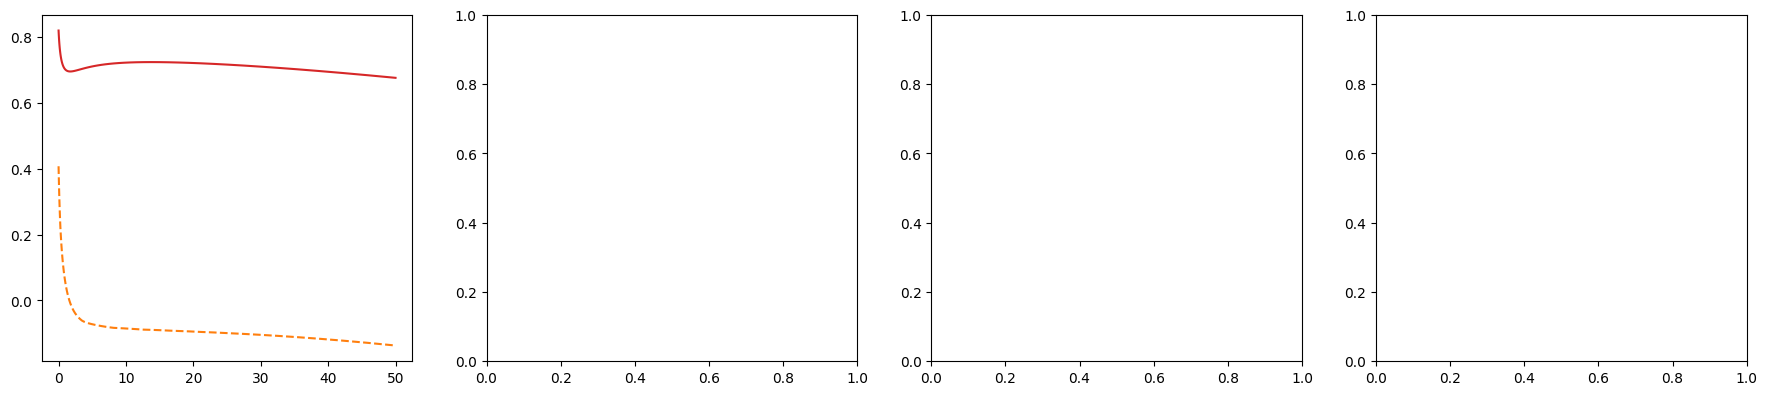

In [73]:
"""Optimise a shared guard width g (bounded between 0.05 and 0.2) for GBSR m = 2 across all distances and visualise the results."""
from scipy.optimize import minimize
from scipy.special import expit, logit

G_MIN = 0.1
G_MAX = 0.4
G_RANGE = G_MAX - G_MIN

def bounded_logit(value: float) -> float:
    """Map a value in [G_MIN, G_MAX] back to the real line for initialisation."""
    clipped = np.clip(value, G_MIN + 1e-6, G_MAX - 1e-6)
    scaled = (clipped - G_MIN) / G_RANGE
    return float(logit(scaled))

def decode_shared_guard(raw_param) -> float:
    """Map an unconstrained parameter to the shared guard width within [0.05, 0.2]."""
    raw_scalar = float(np.ravel(raw_param)[0])
    g_shared = G_MIN + G_RANGE * expit(raw_scalar)
    return g_shared

def build_uniform_guard_array(g_shared: float):
    """Construct the symmetric guard array when every guard takes the same value."""
    g = float(np.clip(g_shared, G_MIN, G_MAX))
    return [
        [0.0, 0.0],
        [g, g],
        [g, g],
        [g, g],
        [0.0, 0.0],
    ]

gbsr_m2_guard_shared = []
gbsr_m2_key_rates = []
gbsr_m2_bits_sent = []
gbsr_m2_bits_leaked = []
gbsr_m2_pass_probabilities = []
gbsr_m2_raw_error_rates = []
gbsr_m2_error_rates = []
gbsr_m2_leak_per_bit = []
gbsr_m2_etas = []
gbsr_m2_holevo = []

initial_guess_g = 0.1
safe_initial = np.array([bounded_logit(initial_guess_g)], dtype=float)
raw_param_guess = safe_initial.copy()

progress_iter = tqdm(range(len(distances_km)), desc="GBSR m=2 actual", leave=False)
for idx in progress_iter:
    distance_km = float(distances_km[idx])
    v_mod = float(surrogate_m2_vmods[idx])
    u_val = float(surrogate_m2_us[idx])
    tau_opt = [-np.inf, -u_val, 0.0, u_val, np.inf]

    T = fibre_transmittance(distance_km)
    xi_excess = float(excess_noise_from_distance(distance_km))

    gbsr_candidate = GBSR(
        m=2,
        modulation_variance=v_mod,
        transmittance=float(T),
        excess_noise=xi_excess,
        Delta_QCT=Delta_QCT,
        code_efficiency=eta_c,
    )
    holevo_term = gbsr_candidate._holevo_with_qct()
    gbsr_m2_holevo.append(holevo_term)

    def neg_actual_key(raw_param):
        g_shared = decode_shared_guard(raw_param)
        if 2.0 * g_shared >= 0.995 * u_val:
            return 1e3 + (2.0 * g_shared - 0.995 * u_val) ** 2
        guard_arr = build_uniform_guard_array(g_shared)
        metrics = gbsr_candidate.evaluate_reconciliation_efficiency(
            tau_opt,
            guard_arr,
            bit_assignment="Gray",
        )
        p_pass = metrics["p_pass"]
        h_t = metrics["quantisation_entropy"]
        leak_per_bit = metrics["leak_per_bit"]
        return -(p_pass * (h_t - leak_per_bit - holevo_term))

    result = minimize(
        neg_actual_key,
        x0=raw_param_guess,
        method="L-BFGS-B",
        options={"maxiter": 200, "gtol": 1e-06, "maxls": 50},
    )
    if not result.success:
        raise RuntimeError(
            f"GBSR m=2 guard-band optimisation failed at {distance_km:.3f} km: {result.message}"
        )

    raw_param_guess = np.array(result.x, dtype=float)
    g_shared_opt = decode_shared_guard(raw_param_guess)
    guard_arr_opt = build_uniform_guard_array(g_shared_opt)

    metrics_opt = gbsr_candidate.evaluate_reconciliation_efficiency(
        tau_opt,
        guard_arr_opt,
        bit_assignment="Gray",
    )
    p_pass_opt = metrics_opt["p_pass"]
    h_t_opt = metrics_opt["quantisation_entropy"]
    leak_per_bit_opt = metrics_opt["leak_per_bit"]
    key_rate_opt = p_pass_opt * (h_t_opt - leak_per_bit_opt - holevo_term)

    gbsr_m2_guard_shared.append(g_shared_opt)
    gbsr_m2_key_rates.append(key_rate_opt)
    gbsr_m2_bits_sent.append(metrics_opt["bits_sent"])
    gbsr_m2_bits_leaked.append(metrics_opt["bits_leaked"])
    gbsr_m2_pass_probabilities.append(p_pass_opt)
    gbsr_m2_raw_error_rates.append(metrics_opt["raw_error_rate"])
    gbsr_m2_error_rates.append(metrics_opt["error_rate"])
    gbsr_m2_leak_per_bit.append(leak_per_bit_opt)
    gbsr_m2_etas.append(metrics_opt["eta"])

gbsr_m2_guard_shared = np.array(gbsr_m2_guard_shared)
gbsr_m2_key_rates = np.array(gbsr_m2_key_rates)
gbsr_m2_bits_sent = np.array(gbsr_m2_bits_sent)
gbsr_m2_bits_leaked = np.array(gbsr_m2_bits_leaked)
gbsr_m2_pass_probabilities = np.array(gbsr_m2_pass_probabilities)
gbsr_m2_raw_error_rates = np.array(gbsr_m2_raw_error_rates)
gbsr_m2_error_rates = np.array(gbsr_m2_error_rates)
gbsr_m2_leak_per_bit = np.array(gbsr_m2_leak_per_bit)
gbsr_m2_etas = np.array(gbsr_m2_etas)
gbsr_m2_holevo = np.array(gbsr_m2_holevo)

gbsr_m2_numerator_bits = gbsr_m2_bits_sent - gbsr_m2_bits_leaked
pass_safe = np.clip(gbsr_m2_pass_probabilities, 1e-12, None)
with np.errstate(divide="ignore", invalid="ignore"):
    gbsr_m2_bits_sent_per_accept = np.divide(gbsr_m2_bits_sent, pass_safe)
    gbsr_m2_bits_leaked_per_accept = np.divide(gbsr_m2_bits_leaked, pass_safe)
    gbsr_m2_numerator_per_accept = np.divide(gbsr_m2_numerator_bits, pass_safe)
    gbsr_m2_holevo_per_accept = np.divide(gbsr_m2_holevo, pass_safe)
    gbsr_m2_key_per_accept = np.divide(gbsr_m2_key_rates, pass_safe)

tau_negative = -surrogate_m2_us
tau_central = np.zeros_like(surrogate_m2_us)
tau_positive = surrogate_m2_us

fig, axes = plt.subplots(1, 4, figsize=(22, 4.5))
ax_key, ax_pass, ax_guard, ax_bits = axes

ax_key.plot(distances_km, surrogate_m2_actual_key_rates, label="SR m=2 (actual @ sur opt)", color="tab:orange", linestyle="--")
ax_key.plot(distances_km, gbsr_m2_key_rates, label="GBSR m=2 (actual key)", color="tab:red")
if "gbsr_m1_key_rates" in globals():
    ax_key.plot(distances_km, gbsr_m1_key_rates, label="GBSR m=1 (actual key)", color="tab:blue", linestyle=":")
ax_key.set_xlabel("Distance (km)")
ax_key.set_ylabel("Bits per pulse")
ax_key.set_title("Actual key comparison (m = 1 vs m = 2)")
ax_key.set_xscale("log")
ax_key.set_yscale("log")
ax_key.set_xlim(1e-2, 1e2)
ax_key.grid(True, which="both", alpha=0.35)
ax_key.legend()

ax_pass.plot(distances_km, gbsr_m2_pass_probabilities, color="tab:green")
ax_pass.set_xlabel("Distance (km)")
ax_pass.set_ylabel("$p_{pass}$")
ax_pass.set_title("GBSR m = 2 pass probability")
ax_pass.set_xscale("log")
ax_pass.set_xlim(1e-2, 1e2)
ax_pass.set_ylim(0.0, 1.05)
ax_pass.grid(True, which="both", alpha=0.35)

color_uniform = "tab:purple"
ax_guard.plot(distances_km, tau_negative, color="tab:red", linestyle="-", label="$\\tau_1$ (outer boundary)")
ax_guard.plot(distances_km, tau_central, color="tab:gray", linestyle="-", label="$\\tau_2$ (central boundary)")
ax_guard.plot(distances_km, tau_positive, color="tab:orange", linestyle="-", label="$\\tau_3$ (inner boundary)")
ax_guard.plot(distances_km, gbsr_m2_guard_shared, color=color_uniform, linestyle=":", label="$g$ (shared guard)")
ax_guard.set_xlabel("Distance (km)")
ax_guard.set_ylabel("Normalised value (units of $\\sigma_B$)")
ax_guard.set_title("Boundaries and shared guard (m = 2)")
ax_guard.set_xscale("log")
ax_guard.set_xlim(1e-2, 1e2)
ax_guard.axhline(0.0, color="black", linestyle="--", linewidth=0.6, alpha=0.4)
ax_guard.grid(True, which="both", alpha=0.35)
ax_guard.legend(ncol=2, fontsize="small")

ax_bits.plot(distances_km, gbsr_m2_bits_sent, label="$p_{pass} H(T)$", color="tab:blue")
ax_bits.plot(distances_km, gbsr_m2_bits_leaked, label="$p_{pass} \\cdot \\text{leak}$", color="tab:orange")
ax_bits.plot(distances_km, gbsr_m2_numerator_bits, label="Numerator", color="tab:green")
ax_bits.plot(distances_km, gbsr_m2_holevo, label="$\\chi$", color="tab:purple")
ax_bits.plot(distances_km, gbsr_m2_key_rates, label="Actual key", color="tab:red", linestyle="--")
ax_bits.set_xlabel("Distance (km)")
ax_bits.set_ylabel("Bits per pulse")
ax_bits.set_title("GBSR m = 2 information terms")
ax_bits.set_xscale("log")
ax_bits.set_xlim(1e-2, 1e2)
ax_bits.grid(True, which="both", alpha=0.35)
ax_bits.legend()

fig.tight_layout()

fig2, ax_accept = plt.subplots(1, 1, figsize=(6.5, 4.2))
ax_accept.plot(distances_km, gbsr_m2_bits_sent_per_accept, label="$H(T)$ per accepted", color="tab:blue")
ax_accept.plot(distances_km, gbsr_m2_bits_leaked_per_accept, label="Leak per accepted", color="tab:orange")
ax_accept.plot(distances_km, gbsr_m2_numerator_per_accept, label="Numerator per accepted", color="tab:green")
ax_accept.plot(distances_km, gbsr_m2_holevo_per_accept, label="$\\chi$ per accepted", color="tab:purple")
ax_accept.plot(distances_km, gbsr_m2_key_per_accept, label="Key per accepted", color="tab:red", linestyle="--")
ax_accept.set_xlabel("Distance (km)")
ax_accept.set_ylabel("Bits per accepted symbol")
ax_accept.set_title("Information balance per accepted symbol (GBSR m = 2)")
ax_accept.set_xscale("log")
ax_accept.set_xlim(1e-2, 1e2)
ax_accept.grid(True, which="both", alpha=0.35)
ax_accept.legend()
fig2.tight_layout()